#### Import Packages

In [1]:
import os
import numpy as np
from numpy import array, rec
from scipy.io import loadmat  # this is the SciPy module that loads mat-files
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import itertools
import torch
import gpytorch
from torch.autograd import Variable
from matplotlib.ticker import MaxNLocator
import json
from json import JSONEncoder
from datetime import datetime
import time
import math
from collections import Counter
 
torch.set_default_dtype(torch.float64)

name_code = 'HGP_BO-test6-priorMAP-1model1D'

#### Get current date and time

In [2]:
current_datetime = datetime.now().strftime("%Y-%m-%d_%Hh-%Mmin-%Ss")
current_dateday = datetime.now().strftime("%Y-%m-%d")

workspace_folder = (r'C:\Users\preda\Documents\Hierarchical and Embedded\Jupyter and Raspberry\HGP-BO') #path to folder

os.chdir(workspace_folder)

folder_of_the_day = (str(workspace_folder) + '/data-' + str(name_code) + str(current_dateday))

if os.path.exists(folder_of_the_day):
    print('Data folder is ready')
else:
    os.mkdir(folder_of_the_day)
    print('Data folder created')

Data folder created


#### JSON encoder to serialize numpy array and saved them in json file

In [3]:
class NumpyArrayEncoder(JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return JSONEncoder.default(self, obj)

#### Parameters 1D

In [4]:
CHS = [13,17,21,18,22,2,6,10,14,9]
# Channels are organized on the following grid
"""
13---17---21---18---22
|    |    |    |    |
2 ---6 ---10---14---9
"""
# which we give the following (x,y) coordinates
"""
(0,1)---(1,1)---(2,1)---(3,1)---(4,1)
  |       |       |       |       |
(0,0)---(1,0)---(2,0)---(3,0)---(4,0)
"""
# and use the following array to map coordinates to channel
xy2ch = [[2,6,10,14,9],
         [13,17,21,18,22]]
ch2xy = {}
for ch in CHS:
    x, y = np.where(np.array(xy2ch) == ch)
    ch2xy[ch] = [x[0],y[0]]
DTS = [0, 10, 20, 40, 60, 80, 100]  # This is the time delay for the stimulation
EMG = 4
N_EMGS = 7

dt = 60
emg = 4

Here are the Hyper parameter settings for the GPBO model

In [5]:
training_iter =  10
nbr_query = 1
q = 0
nbr_rdm_points_ini = 1       # Number of random points to initialize the model
nbr_rdm_points_data = 20     # Number of random points from the Ground Truth (GT) EMG responses to create a dataset
kappa = 2                   
max_seen_resp = 0            # To store the maximum response observed, and normalize between 0 and 1 (arbitrary choice)
nbr_repetition = 2           # Number of repetition of the entire process to average the results
nbr_pins = 10                # Number of channels in the input space

#### Dataset creation

In [6]:
class Trains:

    def __init__(self, emg = EMG, N_EMGS = N_EMGS, path_to_data=None, clean_thresh=None, verbose=False):
        self.chs = CHS
        self.n_ch = len(self.chs)
        self.dts = DTS

        # conditions are
        # 0 : seulement channel A
        # 1: channel A, delay 40ms, channel B
        # 2: channel A, delay 20ms, channel B
        # 3: channel A, delay 10ms, channel B
        # 4: channel A et channel B simultaneous
        # 5: channel B, delay 10ms, channel A
        # 6: channel B, delay 20ms, channel A
        # 7: channel B, delay 40ms, channel A
        # 8:  seulement channel B
        # each cell contains a 20x733 matrix (20 stimulations, 733 time series
        # emg response)
        if path_to_data:
            filtmat = loadmat(os.path.join(path_to_data, 'FilteredPairedTrains.mat'))
        else:
            filtmat = loadmat('FilteredPairedTrains.mat')
        filtdata = filtmat['gfilt_resp']

        # Let's build the datastructure
        # trains[chi][chj][deltat] will contain all timeseries for pair chi, chj
        # with time delay delta_t
        # trains[ch_i][ch_i] will contain single channel pulses
        self.N_EMGS = N_EMGS
        self.emgdct = {}
        for emg in range(N_EMGS):
            # Pairs
            dct = {ch1:{ch2:{} for ch2 in self.chs} for ch1 in self.chs}
            for i,ch1 in enumerate(self.chs):
                for j,ch2 in enumerate(self.chs):
                    # We deal with dt=0 separately, since it should be
                    # symmetric! (ch1,ch2 = ch2,ch1 since stimulations
                    # are done simultaneously (dt=0))
                    if i == j:
                        dct[ch1][ch1][0] = {'data': filtdata[emg,i,j,0]}
                    else:
                        data = filtdata[emg,i,j,0]
                        if data.size == 0:
                            data = filtdata[emg,j,i,0]
                        dct[ch1][ch2][0] = dct[ch2][ch1][0] = {'data': data}
                    ch = dct[ch1][ch2][0]['data']
                    maxs = ch.max(axis=1)
                    dct[ch1][ch2][0]['maxs'] = dct[ch2][ch1][0]['maxs'] = maxs
                    dct[ch1][ch2][0]['meanmax'] = dct[ch2][ch1][0]['meanmax'] = maxs.mean()
                    dct[ch1][ch2][0]['stdmax'] = dct[ch2][ch1][0]['stdmax'] = maxs.std()
                    # Then we deal with dt!=0
                    for k,dt in enumerate(self.dts[1:],1):
                        dct[ch1][ch2][dt] = {'data': filtdata[emg,i,j,k]}
                        # We also precompute the meanmax and stdmax
                        # statistics
                        ch = dct[ch1][ch2][dt]['data']
                        if ch.size != 0:
                            maxs = ch.max(axis=1)
                            dct[ch1][ch2][dt]['maxs'] = maxs
                            dct[ch1][ch2][dt]['meanmax'] = maxs.mean()
                            dct[ch1][ch2][dt]['stdmax'] = maxs.std()
            self.emgdct[emg] = dct

        if clean_thresh:
            # we remove all resps whose max is > clean_thresh
            count = 0
            for emg in range(N_EMGS):
                for ch1 in self.chs:
                    for ch2 in self.chs:
                        for dt in self.dts:
                            if (dt==10 or dt==20) and ch1==ch2:
                                continue
                            maxs = self.emgdct[emg][ch1][ch2][dt]['maxs']
                            i=0
                            while i<len(maxs):
                                if maxs[i] > clean_thresh:
                                    if verbose:
                                        print("Removing resp with max {}".format(maxs[i]))
                                        print("emg {}, ch1 {}, ch2 {}, dt {}".format(emg,ch1,ch2,dt))
                                    count+=1
                                    for other_emg in range(N_EMGS):
                                        data = self.emgdct[other_emg][ch1][ch2][dt]['data']
                                        data = np.delete(data,i,0)
                                        self.emgdct[other_emg][ch1][ch2][dt]['data'] = data
                                        maxs = data.max(axis=1)
                                        self.emgdct[other_emg][ch1][ch2][dt]['maxs']  = maxs
                                        self.emgdct[other_emg][ch1][ch2][dt]['meanmax'] = maxs.mean()
                                        self.emgdct[other_emg][ch1][ch2][dt]['stdmax'] = maxs.std()
                                i+=1
            if verbose:
                print("Removed {} resps in total from dataset".format(count))
        self.trains = self.emgdct[emg]
    
    
    def get_emgdct(self, emg):
        return self.emgdct[emg]
    

    def plot_response_matrix(self, emg=2, syn=None, dt=40, tau=40, title=True, plot_green=True, plot_red=True):
        if syn is None:
            syn = (emg, None)
            emg1 = emg2 = emg
        else:
            emg1,emg2 = syn
        fig = plt.figure()
        if title:
            plt.suptitle("Matrix of responses for EMG1={},EMG2={} with dt={} (1stch left, 2ndch top)".format(*syn, dt))
        gs = gridspec.GridSpec(12,12)
        # We first plot the 1d responses on left and top
        for i, ch in enumerate(self.chs):
            # top
            ax = plt.subplot(gs[0,i+2])
            ax.set_ylim([0,0.05])
            ax.set_xticks([])
            ax.set_yticks([])
            # ax.set_title(ch2xy[ch])
            ax.plot(self.emgdct[emg2][ch][ch][0]['data'].T)
            ax.text(0, 0, "{:.2}".format(self.emgdct[emg2][ch][ch][0]['meanmax']))

            # channel labels top
            ax = plt.subplot(gs[1, i+2])
            ax.text(0, 0.25, ch2xy[ch])
            ax.axis('off')

            # left side
            ax = plt.subplot(gs[i+2,0])
            ax.set_ylim([0,0.05])
            ax.set_xticks([])
            ax.set_yticks([])
            #ax.set_ylabel(ch2xy[ch])
            ax.plot(self.emgdct[emg1][ch][ch][0]['data'].T)
            ax.text(0, 0, "{:.2}".format(self.emgdct[emg1][ch][ch][0]['meanmax']))

            # channel labels left
            ax = plt.subplot(gs[i+2,1])
            ax.text(0.25,0.25,ch2xy[ch])
            ax.axis('off')

        maxch1, maxch2 = self.max_ch_2d(syn=syn,dt=dt)
        maxr = self.synergy_meanmax(*syn, maxch1, maxch2, dt, tau=tau)
        for i, ch1 in enumerate(self.chs):
            for j, ch2 in enumerate(self.chs):
                ax = plt.subplot(gs[i+2, j+2])
                ax.set_ylim([0, 0.05])
                ax.set_xticks([])
                ax.set_yticks([])
                bbox = None
                data = self.synergy(*syn, ch1, ch2, dt, tau=tau)
                if data.size != 0:
                    plt.plot(data.T)
                mm = float(self.synergy_meanmax(*syn, ch1, ch2, dt, tau=tau))
                # if ch1==maxch1 and ch2==maxch2:
                #     bbox = dict(facecolor='green', alpha=0.5)
                if plot_green and mm > maxr - 0.002:
                    bbox = dict(facecolor='green',)
                elif plot_red and mm > maxr - 0.005 and mm < maxr - 0.002:
                    bbox = dict(facecolor='red', alpha=0.5)
                plt.text(0, 0, "{:.2}".format(mm), bbox=bbox)    
                
    def max_ch_2d(self, emg=2, dt=40, syn=None):
        if syn is None:
            syn = (emg,None)
        grid = self.build_f_grid(syn=syn, dt=dt)
        x,y = np.unravel_index(grid.argmax(), grid.shape)
        return [self.chs[x], self.chs[y]]
    
    def build_f_grid(self, emg=2, syn=None, dt=40, f='meanmax'):
        if syn is None:
            syn = (emg, None)
        z_grid = np.zeros((self.n_ch,self.n_ch))
        for i,ch1 in enumerate(self.chs):
            for j,ch2 in enumerate(self.chs):
                #TODO: now with synergies we can only do f='meanmax'
                #      maybe change this later if needed
                z_grid[i][j] = self.synergy_meanmax(*syn,ch1,ch2,dt)
                #self.emgdct[emg][ch1][ch2][dt][f]
        return z_grid
    
    def get_resp(self, emg, dt, ch1, ch2, filldiag=True):
        return self.synergy(emg,emg,ch1,ch2,dt,b=0, filldiag=filldiag)

    def synergy(self, emg1, emg2, ch1, ch2, dt=0, tau=40, a=1, b=1, filldiag=True):
        # synergy is just a linear combination of emgs
        # We use these to define a new cost function (max synergy
        # instead of max of a particular channel)
        # dt is dt between stim pulses
        # tau is how much we shift resp2
        if emg2 is None:
            emg2=0
            b=0
        if filldiag and ch1==ch2 and (dt==10 or dt==20):
            # We don't have values on the diag for dt=10 and dt=20,
            # so we get them from dt=0 if filldiag is True
            dt=0
        resps1 = self.emgdct[emg1][ch1][ch2][dt]['data']
        resps2 = self.emgdct[emg2][ch1][ch2][dt]['data']
        # resps are 1466 (resps1.shape[1]) ticks ts, which last 300ms
        dtidx = int(tau/300*resps1.shape[1])+1
        resps2_shifted = np.zeros_like(resps2)
        resps2_shifted[:,:-dtidx] = resps2[:,dtidx:]
        return a*resps1 + b*resps2_shifted

    def synergy_meanmax(self, emg1, emg2, ch1, ch2, dt=0, tau=40, a=1, b=1):
        syn = self.synergy(emg1,emg2,ch1,ch2,dt,tau,a,b)
        if syn.size == 0:
            return 0
        else:
            return syn.max(axis=1).mean()

#### Create a 1D dataset

In [7]:
def make_dataset_1d(trainsC, emg, n=20):
    # Get the training data for the specified EMG signal.
    trains = trainsC.get_emgdct(emg=emg)

    X = []  # List to store input data points (channel coordinates).
    Y = []  # List to store output data points (EMG signal values).
    Xmean = []  # List to store mean input data points.
    Ymean = []  # List to store mean output data points.
    Yvars = []  # List to store variance of output data points.

    # Loop through all channels and sample 'n' data points per channel.
    for ch in CHS:
        # Randomly sample 'n' maximum values from the data of the current channel.
        ys = random.sample(trains[ch][ch][0]['data'].max(axis=1).tolist(), n)
        Y.extend(ys)  # Add the sampled maximum values to the output data list.

        # Get the variance of the maximum values for the current channel.
        var = trains[ch][ch][0]['stdmax'] ** 2
        Yvars.extend([var] * len(ys))  # Add the variance to the variance list.

        xy = ch2xy[ch]  # Get the (x, y) coordinates of the current channel.
        X.extend([xy] * len(ys))  # Add the coordinates to the input data list.

        # Get the mean value and add it to the mean lists.
        Ymean.append(trains[ch][ch][0]['meanmax'])
        Xmean.extend([xy])

    # If mean is False, convert the input and output lists into numpy arrays and return.
    X = np.array(X)
    Y = np.array(Y).reshape((-1, 1))
    return X, Y, Xmean, Ymean

#### Declaration of a simple 1D GP_model

In [8]:
# We will use the simplest form of GP model, exact inference
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        """
        Initialize the Exact GP model.

        Parameters:
        - train_x (torch.Tensor): Training input data. If 1D [x, y], if 2D [x1, y1, x2, y2]
        - train_y (torch.Tensor): Training output data: EMG values
        - likelihood: Likelihood function.
        """
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu = 2.5))

    def forward(self, x):
        """
        Forward pass of the GP model.

        Parameters:
        - x (torch.Tensor): Input data, can be train or test dataset

        Returns:
        - gpytorch.distributions.MultivariateNormal: Predictive distribution.
        """
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

#### Optimization function

In [9]:
def optimize(model, likelihood, training_iter, train_x, train_y, verbose=True):
    """
    Optimize the GP model.

    Parameters:
    - model: GP model.
    - likelihood: Likelihood function.
    - training_iter (int): Number of optimization iterations.
    - train_x (torch.Tensor): Training input data. . If 1D [x, y], if 2D [x1, y1, x2, y2]
    - train_y (torch.Tensor): Training output data: EMG values
    - verbose (bool): Whether to print optimization progress.

    Returns:
    - model: Optimized GP model.
    - likelihood: Optimized likelihood function.
    """
    # Use the adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(training_iter):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x)
        # Calc loss and backprop gradients
        loss = -mll(output, train_y)
        loss.sum().backward()
        if verbose:
            print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
                i + 1, training_iter, loss.item(),
                model.covar_module.base_kernel.lengthscale.item(),
                model.likelihood.noise.item()
            ))
        optimizer.step()
    return model, likelihood

#### Random data for initialization

In [10]:
def random_initialization_1D(random_sample, emg, trainsC, max_seen_resp):
    """
    Perform random initialization for training points.

    Parameters:
    - random_sample (int): Number of random samples.
    - emg: EMG data.
    - trainsC: Training configuration.

    Returns:
    - X: List of input data.
    - Y: List of output data.
    """
    # Initial random training points
    X = []
    Y = []
    for _ in range(random_sample):
        ch = random.choice(CHS)
        X.append(ch2xy[ch])
        response = random.choice(trainsC.emgdct[emg][ch][ch][dt]['data'].max(axis=1))
        
        # Add of if statement and max seen resp in the case of several initialization points
        if (response > max_seen_resp) or (max_seen_resp == 0):
                max_seen_resp = response
        
        #TODO: see if this normalization makes sense and if not do it correctly
        Y.append(response/response) # need to Normalization between 0 and 1
        
    X = torch.tensor(X, dtype = torch.float64)
    Y = torch.tensor(Y, dtype = torch.float64)
    
    return X, Y

#### Get acquisition map

In [11]:
def get_acquisition_map(kappa, observed_pred) :
    """
    Compute the acquisition map for Bayesian optimization. 
    Here UCB function : a(x;k)=μ(x)+kσ(x)
    
    Parameters:
    - k: kappa (float): Manage the trade-off between exploration and exploitation.
    - observed_pred (gpytorch.distributions.MultivariateNormal): Predictive posterior distribution.

    Returns:
    - acquisition_map (torch.Tensor): Acquisition map.
    - y_mu (torch.Tensor): Mean of the predictive distribution.
    """
    # get the mean (mu) and the variance (sigma2) of the model
    y_mu = observed_pred.mean
    y_sigma2 = observed_pred.variance
    
    # compute acquisition map
    acquisition_map = y_mu + kappa * torch.nan_to_num(torch.sqrt(y_sigma2)) # here UCB acquisition function
    return acquisition_map, y_mu

#### Get next query pins

In [12]:
def get_next_query_pins_from_1D(acquisition_map, coord_pins):
    """
    Determine the next query pins based on the acquisition map.

    Parameters:
    - acquisition_map (torch.Tensor): Acquisition map.
    - coord_pins (numpy.ndarray): Coordinates of pins.

    Returns:
    - next_query_pins (torch.Tensor): Coordinates of the next query pins.
    """
    # get next query pin based on the acquisition map, max return the max value, argmax return indices of the max value
    possible_next_query = torch.topk(acquisition_map, 2)    # Gets the top 2 candidates for acquisition
    indice1 = possible_next_query.indices[0]
    indice2 = possible_next_query.indices[1]
    next_query_pins1 = torch.as_tensor(indice1, dtype=torch.float64)
    next_query_pins2 = torch.as_tensor(indice2, dtype=torch.float64)
    next_query_pins = torch.cat((next_query_pins1, next_query_pins2), 0)
    return next_query_pins

#### Get the new value to update training data and Y_mu point value

In [13]:
def get_next_query_value_1D(next_query_pins, X, Y):
    """
    Get the new value for the next query pins to update training data.

    Parameters:
    - next_query_pins (torch.Tensor): Coordinates of the next query pins.
    - Y (list): List of values for the corresponding pins. 
                Per pins, possible values =  nbr_rdm_points_data

    Returns:
    - new_query_value_random (float): Randomly chosen new value to add to the training dataset.
    - new_query_value_mean (float): Mean value of the corresponding pins to compute exploitation score.
    """
    new_training_values = np.zeros(nbr_rdm_points_data)
    i = 0
    for indices, pins in enumerate(X):
        if pins[0] == next_query_pins[0] and pins[1] == next_query_pins[1]: # find pins of (x, y) coordinates in X
            new_training_values[i] = Y[indices]
            i += 1
    new_query_value_mean = np.mean(new_training_values)
    new_query_value_random = np.random.choice(new_training_values)
    return new_query_value_random, new_query_value_mean


def get_y_mu_point_value(next_query_pins, y_mu, X):
    a = 0
    for indices, pins in enumerate(X):
        if pins[0] == next_query_pins[0] and pins[1] == next_query_pins[1]: # find pins of (x, y) coordinates in X
            ind = indices
    a = y_mu[ind]
    return a

#### Get exploration and exploitation score

In [14]:
def get_exploration_score_model_1D(y_mu, ground_truth_max, coord_pins, X, Y):
    """
    Compute the exploration score.

    Parameters:
    - y_mu (torch.Tensor): Mean of the predictive distribution.
    - ground_truth_max (float): Maximum ground truth value.
    - coord_pins (numpy.ndarray): Coordinates of pins.
    - Y (list): List of values for the corresponding pins.

    Returns:
    - exploration_score (float): Exploration score.
    - next_query_pins (torch.Tensor): Coordinates of the next query pins to explore.
    
    Comments: X and Y represent the coord and respective values of GT, size of nbr_rdm_points_data 
    """
    values_for_mean = np.zeros(nbr_rdm_points_data)
    i = 0
    mu = y_mu
    argmax_mu = torch.where(mu.reshape(len(mu))==torch.max(mu.reshape(len(mu))))

    # randomly choose a query if there are multiple max values
    if len(argmax_mu[0])>1:                                                  #  If there are several max values, choose randomly among these max values
        indice_next_query = np.random.randint(len(argmax_mu[0]))  # Retrieves the index of the next query randomly among the indices offering the max value
        next_query = argmax_mu[0][indice_next_query]  # Coordinates (x, y) corresponding to the selected max value
        next_query_pins = torch.as_tensor(coord_pins[next_query], dtype=torch.float64)  # Retrieves the coordinates of the pins and the corresponding value

    else:
        next_query = argmax_mu[0][0]
        next_query_pins = torch.as_tensor(coord_pins[next_query], dtype=torch.float64)
        
    for indices, pins in enumerate(X):
        if pins[0] == next_query_pins[0] and pins[1] == next_query_pins[1]: # find pins of (x, y) coordinates in X
            values_for_mean[i] = Y[indices]
            i += 1
            
    mean_value = np.mean(values_for_mean)
    exploration_score = mean_value / ground_truth_max #TODO: Is this really how we want to calculate the exploration score?
    return exploration_score, next_query_pins


def get_exploitation_score_model_1D(mean_value, ground_truth_max):
    """
    Compute the exploitation score.

    Parameters:
    - mean_value (float): Mean value of the corresponding selected pin.
    - ground_truth_max (float): Maximum ground truth value.

    Returns:
    - exploitation_score (float): Exploitation score.
    """
    exploitation_score = mean_value / ground_truth_max
    return exploitation_score
    

#### Update training data

In [15]:
def update_training_data(train_x, train_y, next_query_pins, next_query_value):
    """
    Update the training data with the new query values.

    Parameters:
    - train_x (torch.Tensor): Training input data.
    - train_y (torch.Tensor): Training output data.
    - next_query_pins (torch.Tensor): Coordinates of the next query pins.
    - next_query_value (float): Value for the next query.

    Returns:
    - train_x (torch.Tensor): Updated training input data. (pin coordinates)
    - train_y (torch.Tensor): Updated training output data. (pin value)
    """
    train_x = list(train_x)
    train_y = list(train_y)
    train_x.append(next_query_pins)
    train_y.append(next_query_value)
    train_x = torch.stack(train_x)
    train_y = torch.as_tensor(train_y) # torch.as_tensor avoids copying the tensor in memory again, unlike torch.tensor

    return train_x, train_y

#### Make a prediction on the next query

In [16]:
def make_prediction(model, x, likelihood):
    """
    Make a prediction on the next query.

    Parameters:
    - model: GP model.
    - x (torch.Tensor): Input data. (pins coordinates)

    Returns:
    - observed_pred (gpytorch.distributions.MultivariateNormal): Predicted distribution.
    """
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed_pred = likelihood(model(x))
        return observed_pred

#### Count number of times a pin is selected

In [17]:
#TODO: verify, maybe not working properly for HGP-BO
def count_pin(selected_pin_array, x): 
    """
    Count the occurrences of each pin in the selected pin array.

    Parameters:
    - selected_pin_array (torch.Tensor): Array containing selected pin to count.
    - x (torch.Tensor): Array of pin coordinates, e.g., see above

    Returns:
    - arr_count (np.ndarray): Array containing the count of occurrences for each pin.
    """
    arr = tuple(map(tuple, (selected_pin_array))) # set the selected_pin_array as tuple to be iterable by Counter
    count_occurences = Counter(arr)               # return the counting value but not the zeros
    count_occurences = {torch.tensor(k):int(v) for k,v in count_occurences.items()}
    
    dict_pins = {}                                # set a new dict with key as all pins coordinates and value 0
    for i in x:
        dict_pins[i] = 0 
    
    for key1 in dict_pins:                        # compare both dict and replace value of dict_pins by corresponding count_occurences value if both key are the same
        for key2 in count_occurences:
            if (key1[0] == key2[0] and key1[1] == key2[1]):
                dict_pins[key1] = count_occurences.get(key2)
    
    result = dict_pins.items()
    result_list = list(result)
    arr_count = np.array(result_list, dtype="object") # change from tensor to array to be serialize and saved as json
    
    for i in range(len(arr_count)):
        arr_count[i][0] = np.array(arr_count[i][0])
    
    return arr_count

#### Reset data storage

In [18]:
def reset_data_storage(dict_of_array):
    """
    Reset data storage for the next repetition.

    Parameters:
    - dict_of_array: dictionnary of arrays to reset

    Returns:
    - dict_of_array: : dictionnary of arrays set to zero
    """
    
    for keys, array in dict_of_array.items():
        if keys == 'kappa_value' or keys == 'nbr_of_repetition' or keys == 'nbr_of_query_per_rep' or keys == 'pts_of_ini' or keys == 'emg':
            pass
        elif type(array)==list:
            array = [] 
        else:
            array.fill(0)
            
    return dict_of_array

#### Confidence determination

In [19]:
def get_confidence_exploration(tensor_lower, tensor_upper, pins_exploration, test_coord):
    """
    Get confidence bounds for exploration.

    Parameters:
    - tensor_lower (torch.Tensor): Lower confidence bounds tensor. (from make_prediction)
    - tensor_upper (torch.Tensor): Upper confidence bounds tensor.
    - pins_exploration (torch.Tensor): Coordinates of the pins for exploration.
    - test_coord: Array of test coordinates.

    Returns:
    - conf_low (torch.Tensor): Lower confidence bound for the specified exploration pins.
    - conf_up (torch.Tensor): Upper confidence bound for the specified exploration pins.
    """
    for indices, pins in enumerate(test_coord):
        if pins_exploration[0] == pins[0] and pins_exploration[1] == pins[1]: # find pins of (x, y) coordinates in X
            conf_low = tensor_lower[indices]
            conf_up = tensor_upper[indices]
    return conf_low, conf_up

def get_confidence_exploitation(tensor_lower, tensor_upper, pins_exploitation, test_coord):
    """
    Get confidence bounds for exploitation.

    Parameters:
    - tensor_lower (torch.Tensor): Lower confidence bounds tensor.
    - tensor_upper (torch.Tensor): Upper confidence bounds tensor.
    - pins_exploitation (torch.Tensor): Coordinates of the pins for exploitation.
    - test_coord: Array of test coordinates.

    Returns:
    - conf_low (torch.Tensor): Lower confidence bound for the specified exploitation pins.
    - conf_up (torch.Tensor): Upper confidence bound for the specified exploitation pins.
    """
    for indices, pins in enumerate(test_coord):
        if pins_exploitation[0] == pins[0] and pins_exploitation[1] == pins[1]: # find pins of (x, y) coordinates in X
            conf_low = tensor_lower[indices]
            conf_up = tensor_upper[indices]
    return conf_low, conf_up

#### Compute execution time

In [20]:
def compute_execution_time(executionTime_repetitions, startTime, nbr_repetition, nbr_query, folder_of_the_day, workspace_folder):
    # Compute execution time
    time_per_query = executionTime_repetitions/(nbr_repetition*nbr_query)
    time_per_repetition = executionTime_repetitions/nbr_repetition
    time_per_parameter = executionTime_repetitions
    print('Time per query: ' + str(time_per_query) + ' s')            # time for one query
    print('Time per repetition: ' + str(time_per_repetition) + ' s')  # time for one repetition
    print('Time per parameter: ' + str(time_per_parameter) + ' s')    # time for one parameter evaluation

    # Compute total execution time
    executionTime = (time.time() - startTime)
    print('Query per repetition: ' + str(nbr_query))
    print('Repetition per parameter tested: ' + str(nbr_repetition))
    print('Total execution time in seconds: ' + str(executionTime) + ' s') # total time to evaluate all parameters
    startTime = time.time()

    time_dict={'number_of_query':nbr_query,
               'time_per_query':time_per_query,
               'number_of_repetition':nbr_repetition,
               'time_per_repetition':time_per_repetition,
               'time_per_parameter':time_per_parameter,
               'total_time':executionTime}

    # Go to the folder of the day and save data
    os.chdir(folder_of_the_day)
    with open(str('time_of_run') + '.json', 'w') as file:
        json.dump(time_dict, file, cls=NumpyArrayEncoder)
    # Go back to workspace
    os.chdir(workspace_folder)

#### Save data

In [21]:
def save_data(file_name, folder_of_the_day, workspace_folder, data_dict):
    # Go to the folder of the day and save data
    os.chdir(folder_of_the_day)
    with open(str(file_name) + '.json', 'w') as file:
        json.dump(data_dict, file, cls=NumpyArrayEncoder)
    # Go back to workspace
    os.chdir(workspace_folder)

#### Train 1D model

In [22]:
def train_model1D(model, likelihood, training_iter, train_x, train_y, test_x, GT_max, kappa, nbr_repetition, nbr_query, nbr_rdm_points_ini, nbr_pins, emg, trainsC, Y):
    # Prepare data storage
    #-------------------------------------------------------------------------
    # Array for saving data of each query
    array_repetition = np.zeros(nbr_query*nbr_repetition)
    array_query = np.zeros(nbr_query*nbr_repetition)
    # Array for the exploitation and exploration scores
    array_exploration_score = np.zeros(nbr_query*nbr_repetition)
    array_exploitation_score = np.zeros(nbr_query*nbr_repetition)
    # Array for the mean of the #query over all repetitions
    array_explr_mean = np.zeros(nbr_query)
    array_explt_mean = np.zeros(nbr_query)
    # Array for the mean confidence low and up of each score of the #query
    array_confUp_explr_mean = np.zeros(nbr_query)
    array_confUp_explt_mean = np.zeros(nbr_query)
    array_confLow_explr_mean = np.zeros(nbr_query)
    array_confLow_explt_mean = np.zeros(nbr_query)
    # Array for exploration and exploitation pins selected
    array_pins_coord = np.zeros(((nbr_query*nbr_repetition), 2))
    array_pins_coord_exploration = np.zeros(((nbr_query*nbr_repetition), 2))
    # Array for counting each exploration and exploitation pins selected
    array_pins_count_exploration = np.zeros(nbr_pins)
    array_pins_count = np.zeros(nbr_pins)
    #-------------------------------------------------------------------------
    
    # Start running the entire process for nbr_repetition
    for repetition in range(nbr_repetition):
        startTime_repetition = time.time()
        max_seen_resp = 0

        # Start training and evaluating over a number of query
        for q in range (nbr_query):
            if q == 0: # If first query
                # Get into evaluation (predictive posterior) mode
                model.eval()
                likelihood.eval()

                # Make a prediction, observed_pred = likelihood, prediction_mean = mu
                observed_pred = make_prediction(model, test_x, likelihood)

            acquisition_map, y_mu = get_acquisition_map(kappa, observed_pred)

            # Get the coordinates of the next pins to exploite
            next_query_pins = get_next_query_pins(acquisition_map, test_x)

            # Get the 20 values in the GT dataset corresponding to the next pin
            # Random is for update training data, random value choose between the 20 values of the GT
            # Mean is for the exploitation score computation, mean of the 20 values of the GT
            next_query_value_random, next_query_value_mean = get_next_query_value(next_query_pins, Y)

            # Update the max seen response if necessary
            if (next_query_value_random > max_seen_resp) or (max_seen_resp == 0):
                max_seen_resp = next_query_value_random
            next_query_value_random = next_query_value_random / max_seen_resp

            # Update training data by adding next_query_value to the train dataset
            train_x, train_y = update_training_data(train_x, train_y, next_query_pins, next_query_value_random)

            # Update the model with the new training data
            model.set_train_data(train_x, train_y, strict = False) # strict = False to add inputs with different shape

            # Find optimal model hyperparameters
            model.train()
            likelihood.train()

            model, likelihood = optimize(model, likelihood, training_iter, train_x, train_y)

            # Get into evaluation (predictive posterior) mode
            model.eval()
            likelihood.eval()

            # Make a prediction, observed_pred = likelihood, prediction_mean = y_mu
            observed_pred = make_prediction(model, test_x, likelihood)

            #-----------------------------------------------------------------------------------------------#
            # Compute exploration and exploitation score
            exploration_score, next_query_pins_exploration = get_exploration_score(y_mu, GT_max, test_x, Y)
            exploitation_score = get_exploitation_score(next_query_value_mean, GT_max)
            # Record results and parameters
            # Query and repetitions
            array_repetition[q + nbr_query * repetition] = repetition
            array_query[q + nbr_query * repetition] = q
            # Scores and confidence
            array_exploration_score[q + nbr_query * repetition] = exploration_score
            array_exploitation_score[q + nbr_query * repetition] = exploitation_score
            # Pins selected
            array_pins_coord[q + nbr_query * repetition][:] = next_query_pins
            array_pins_coord_exploration[q + nbr_query * repetition][:] = next_query_pins_exploration
            # Mean for each score and confidence level of a query over all rep
            array_explr_mean[q] += (array_exploration_score[q + nbr_query * repetition]) 
            array_explt_mean[q] += (array_exploitation_score[q + nbr_query * repetition])
            #-----------------------------------------------------------------------------------------------#
            
    executionTime_repetitions = (time.time() - startTime_repetition)
    
    # Compute the mean of score and confidence level on each line which accumulated value over repetitions
    for q in range (nbr_query):
        array_explr_mean[q] = array_explr_mean[q]/nbr_repetition
        array_explt_mean[q] = array_explt_mean[q]/nbr_repetition
        array_confUp_explr_mean[q] = array_explr_mean[q] + (np.std(array_explr_mean, axis=0)/nbr_repetition)/math.sqrt(nbr_repetition)  # mean +/- (SD/sqrt(query))
        array_confUp_explt_mean[q] = array_explt_mean[q] + (np.std(array_explt_mean, axis=0)/nbr_repetition)/math.sqrt(nbr_repetition)
        array_confLow_explr_mean[q] = array_explr_mean[q] - (np.std(array_explr_mean, axis=0)/nbr_repetition)/math.sqrt(nbr_repetition)
        array_confLow_explt_mean[q] = array_explt_mean[q] - (np.std(array_explt_mean, axis=0)/nbr_repetition)/math.sqrt(nbr_repetition)

    array_pins_count = count_pin(array_pins_coord, test_x)
    array_pins_count_exploration = count_pin(array_pins_coord_exploration, test_x)   

    data_dict={'query_number':array_query,
              'exploration_score':array_exploration_score,
              'exploitation_score':array_exploitation_score,
              'pins_coord_exploration':array_pins_coord_exploration,
              'pins_count_exploration':array_pins_count_exploration,
              'pins_coord_exploitation':array_pins_coord,
              'pins_count_exploitation':array_pins_count,
              'exploration_score_mean_repetition':array_explr_mean,
              'exploitation_score_mean_repetition':array_explt_mean,
              'kappa_value':kappa,
              'nbr_of_query_per_rep':nbr_query,
              'nbr_of_repetition':nbr_repetition,
              'pts_of_ini':nbr_rdm_points_ini
              }
    
    return model, train_x, train_y, max_seen_resp, data_dict, executionTime_repetitions

#### Create data storage

In [23]:
def create_data_storage(nbr_query, nbr_repetition, nbr_pins):
    #TODO: convert all the returned arrays into a dictionary to make things easier
    # Array for saving data of each query
    array_repetition = np.zeros(nbr_query*nbr_repetition)
    array_query = np.zeros(nbr_query*nbr_repetition)
    # Array for the exploitation and exploration scores
    array_exploration_score = np.zeros(nbr_query*nbr_repetition)
    array_exploitation_score = np.zeros(nbr_query*nbr_repetition)
    # Array for the mean of the #query over all repetitions
    array_explr_mean = np.zeros(nbr_query)
    array_explt_mean = np.zeros(nbr_query)
    # Array for the mean confidence low and up of each score of the #query
    array_confUp_explr_mean = np.zeros(nbr_query)
    array_confUp_explt_mean = np.zeros(nbr_query)
    array_confLow_explr_mean = np.zeros(nbr_query)
    array_confLow_explt_mean = np.zeros(nbr_query)
    # Array for exploration and exploitation pins selected
    array_pins_coord = np.zeros(((nbr_query*nbr_repetition), 4))
    array_pins_coord_exploration = np.zeros(((nbr_query*nbr_repetition), 4))
    # Array for counting each exploration and exploitation pins selected
    array_pins_count_exploration = np.zeros(nbr_pins)
    array_pins_count = np.zeros(nbr_pins)
    
    return array_repetition, array_query, array_exploration_score, array_exploitation_score, array_explr_mean, array_explt_mean, array_confUp_explr_mean, array_confUp_explt_mean, array_confLow_explr_mean, array_confLow_explt_mean, array_pins_coord, array_pins_coord_exploration, array_pins_count_exploration, array_pins_count

def create_data_storage_1D(nbr_query, nbr_repetition, nbr_pins):
    # Array for saving data of each query
    array_repetition = np.zeros(nbr_query*nbr_repetition)
    array_query = np.zeros(nbr_query*nbr_repetition)
    # Array for the exploitation and exploration scores
    array_exploration_score = np.zeros(nbr_query*nbr_repetition)
    array_exploitation_score = np.zeros(nbr_query*nbr_repetition)
    # Array for the mean of the #query over all repetitions
    array_explr_mean = np.zeros(nbr_query)
    array_explt_mean = np.zeros(nbr_query)
    # Array for the mean confidence low and up of each score of the #query
    array_confUp_explr_mean = np.zeros(nbr_query)
    array_confUp_explt_mean = np.zeros(nbr_query)
    array_confLow_explr_mean = np.zeros(nbr_query)
    array_confLow_explt_mean = np.zeros(nbr_query)
    # Array for exploration and exploitation pins selected
    array_pins_coord = np.zeros(((nbr_query*nbr_repetition), 2))
    array_pins_coord_exploration = np.zeros(((nbr_query*nbr_repetition), 2))
    # Array for counting each exploration and exploitation pins selected
    array_pins_count_exploration = np.zeros(nbr_pins)
    array_pins_count = np.zeros(nbr_pins)
    
    return array_repetition, array_query, array_exploration_score, array_exploitation_score, array_explr_mean, array_explt_mean, array_confUp_explr_mean, array_confUp_explt_mean, array_confLow_explr_mean, array_confLow_explt_mean, array_pins_coord, array_pins_coord_exploration, array_pins_count_exploration, array_pins_count

#### Update maximum seen response

In [24]:
def update_max_seen_response(next_query_value_random, max_seen_resp):
        #TODO: Update the max seen response if necessary MODEL HIERARCHIQUE
        if (next_query_value_random > max_seen_resp) or (max_seen_resp == 0):
            max_seen_resp = next_query_value_random
        next_query_value_random = next_query_value_random / max_seen_resp
        return next_query_value_random, max_seen_resp

#### comparison prior map et observed pred

In [25]:
def heatmap_custom(map_name, q, data, row_labels, col_labels, ax=None,
            cbar_kw=None, cbarlabel="", **kwargs):
    """
    Create a heatmap from a numpy array and two lists of labels.

    Parameters
    ----------
    data
        A 2D numpy array of shape (M, N).
    row_labels
        A list or array of length M with the labels for the rows.
    col_labels
        A list or array of length N with the labels for the columns.
    ax
        A `matplotlib.axes.Axes` instance to which the heatmap is plotted.  If
        not provided, use current axes or create a new one.  Optional.
    cbar_kw
        A dictionary with arguments to `matplotlib.Figure.colorbar`.  Optional.
    cbarlabel
        The label for the colorbar.  Optional.
    **kwargs
        All other arguments are forwarded to `imshow`.
    """
    
    if ax is None:
        ax = plt.gca()

    if cbar_kw is None:
        cbar_kw = {}

    # Plot the heatmap
    im = ax.imshow(data, **kwargs)

    if map_name == 'prior': 
        ax.set_title('Prior Map - Query ' + str(q))
    elif map_name == 'observed_pred': 
        ax.set_title('Prediction Mean - Query ' + str(q))
    
    # Create colorbar
    cbar = ax.figure.colorbar(im, fraction=0.046, pad=0.04, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    # Show all ticks and label them with the respective list entries.
    ax.set_xticks(np.arange(data.shape[1]), labels=col_labels)
    ax.set_yticks(np.arange(data.shape[0]), labels=row_labels)

    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=True, bottom=False,
                   labeltop=True, labelbottom=False)

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="left", rotation_mode="anchor")

    # Turn spines off and create white grid.
    ax.spines[:].set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar


def annotate_heatmap(im, data=None, valfmt="{x:.2f}",
                     textcolors=("black", "white"),
                     threshold=None, **textkw):
    """
    A function to annotate a heatmap.

    Parameters
    ----------
    im
        The AxesImage to be labeled.
    data
        Data used to annotate.  If None, the image's data is used.  Optional.
    valfmt
        The format of the annotations inside the heatmap.  This should either
        use the string format method, e.g. "$ {x:.2f}", or be a
        `matplotlib.ticker.Formatter`.  Optional.
    textcolors
        A pair of colors.  The first is used for values below a threshold,
        the second for those above.  Optional.
    threshold
        Value in data units according to which the colors from textcolors are
        applied.  If None (the default) uses the middle of the colormap as
        separation.  Optional.
    **kwargs
        All other arguments are forwarded to each call to `text` used to create
        the text labels.
    """

    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    # Normalize the threshold to the images color range.
    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max())/2.

    # Set default alignment to center, but allow it to be
    # overwritten by textkw.
    kw = dict(horizontalalignment="center",
              verticalalignment="center")
    kw.update(textkw)

    # Get the formatter in case a string is supplied
    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)

    # Loop over the data and create a `Text` for each "pixel".
    # Change the text's color depending on the data.
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
            text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)

    return texts

In [26]:
def comparison(list_prior, list_pred, q, Xmean_1D):
    """
    Compares the prior to the observed predictions of the model by plotting heatmaps
    Args:
        list_prior: 
        list_pred: 
        q: 
        Xmean_1D: 

    Returns:

    """
    
    font = {'weight' : 'normal',
           'size'   : 12}
    matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
    matplotlib.rc('text', usetex=True)
        
    if (q%10)==0:
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 10))
        
        map_name = 'prior'
        im1, cbar1 = heatmap_custom(map_name, q, list_prior[-1], Xmean_1D, Xmean_1D, ax=ax1,
                           cmap="Greens", cbarlabel="Normalized value")
        texts = annotate_heatmap(im1, data=list_prior[-1], valfmt="{x:.2f}")
        
        map_name = 'observed_pred'
        im2, cbar2 = heatmap_custom(map_name, q, list_pred[-1], Xmean_1D, Xmean_1D, ax=ax2,
                           cmap="Greens", cbarlabel="Normalized value")
        texts = annotate_heatmap(im2, data=list_pred[-1], valfmt="{x:.2f}")

        fig.tight_layout()
        plt.show()
    else:
        pass

# Hierarchical Class

In [27]:
class PriorMean(gpytorch.means.Mean): #PMF
    def __init__(self, prior_map):
        super().__init__()
        self.register_parameter('map',torch.nn.Parameter(prior_map, requires_grad=False))

    def forward(self, input):
        if input.shape[0]==1:
            first_indice = input[0, 0:2]
            for indices, pins in enumerate(Xmean_1D):
                if (pins[0] == first_indice[0] and pins[1] == first_indice[1]):
                    indice_1 = indices
            second_indice = input[0, 2:4]
            for indices, pins in enumerate(Xmean_1D):
                if (pins[0] == second_indice[0] and pins[1] == second_indice[1]):
                    indice_2 = indices

            new_prior=self.map[indice_1, indice_2].reshape(1,)
            
        else:
            new_prior = torch.zeros(input.shape[0])
            input=input.long()

            for i in range(input.shape[0]):
                first_indice = input[i, 0:2]
                for indices, pins in enumerate(Xmean_1D):
                    if (pins[0] == first_indice[0] and pins[1] == first_indice[1]):
                        indice_1 = indices
                second_indice = input[i, 2:4]
                for indices, pins in enumerate(Xmean_1D):
                    if (pins[0] == second_indice[0] and pins[1] == second_indice[1]):
                        indice_2 = indices

                new_prior[i]=self.map[indice_1, indice_2]
        
        return new_prior

class Hierarchical_GP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, hierarchical_kernel, prior_map):
        super(Hierarchical_GP, self).__init__(train_x, train_y, likelihood)
        
        self.mean_module = PriorMean(prior_map)
        self.mean_module.requires_grad=False
        self.covar_module = hierarchical_kernel

    def forward(self, x):
        #print('x',x)
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def hierarchical_kernel(kernel_type, model1, model2):
    if kernel_type == 'add':
        kernel1 = gpytorch.kernels.MaternKernel(nu=2.5,  has_lengthscale=True, ard_num_dims=2, input_dim=4, active_dims=[0,1])
        kernel1.outputscale = model1.covar_module.outputscale
        kernel1.lengthscale = model1.covar_module.base_kernel.lengthscale

        kernel2 = gpytorch.kernels.MaternKernel(nu=2.5,  has_lengthscale=True, ard_num_dims=2, input_dim=4, active_dims=[2,3])
        kernel2.outputscale = model2.covar_module.outputscale
        kernel2.lengthscale = model2.covar_module.base_kernel.lengthscale

        hierarchical_kernel = kernel1 + kernel2
    return hierarchical_kernel    

def update_kernel_parameters(model, model1, model2):
        model.covar_module.kernels[0].outputscale = model1.covar_module.outputscale
        model.covar_module.kernels[0].lengthscale = model1.covar_module.base_kernel.lengthscale
        
        model.covar_module.kernels[1].outputscale = model2.covar_module.outputscale
        model.covar_module.kernels[1].lengthscale = model2.covar_module.base_kernel.lengthscale
        return model

#### Build Hierarchical Mean and Hierarchical Kernel

In [28]:
def prediction_model1_1D(model, likelihood, test_x, Xmean, coord_hierarchique, model_number):
    # Get into evaluation (predictive posterior) mode
    model.eval()
    likelihood.eval()
    # Make a prediction, observed_pred = likelihood, prediction_mean = y_mu
    observed_pred = make_prediction(model, test_x, likelihood)
    
    y_mu_matrix = observed_pred.mean
    
    if model_number == '1':
        coord = coord_hierarchique[0:2]
    elif model_number == '2':
        coord = coord_hierarchique[2:4]

    for indices, pins in enumerate(Xmean):
        if pins[0] == coord[0] and pins[0] == coord[0]:
            indice_value = indices
            y_mu = y_mu_matrix[indice_value]
            
    return y_mu
    
def compute_responses(y_mu1, y_mu2, response_hierarchique):
    y_mu1 = torch.as_tensor(y_mu1)
    y_mu2 = torch.as_tensor(y_mu2)
    response_1 = (response_hierarchique-y_mu1)/y_mu2
    response_2 = (response_hierarchique-y_mu2)/y_mu1
    return response_1, response_2
    
def update_model1_1D(model, likelihood, train_x, train_y, next_query_pins, response1, response2):
    # Update training data by adding next_query_value to the train dataset
    train_x, train_y = update_training_data(train_x, train_y, next_query_pins[0:2], response1) # has to be 1D dataset
    train_x, train_y = update_training_data(train_x, train_y, next_query_pins[2:4], response2) # has to be 1D dataset
    # Update the model with the new training data
    model.set_train_data(train_x, train_y, strict = False)
    # Find optimal model hyperparameters
    model.train()
    likelihood.train()

    model, likelihood = optimize(model, likelihood, training_iter, train_x, train_y)
    
    return model, likelihood, train_x, train_y

#### Parameters 2D

In [29]:
CHS = [13,17,21,18,22,2,6,10,14,9]
# Channels are organized on the following grid
"""
13---17---21---18---22
|    |    |    |    |
2 ---6 ---10---14---9
"""
# which we give the following (x,y) coordinates
"""
(0,1)---(1,1)---(2,1)---(3,1)---(4,1)
  |       |       |       |       |
(0,0)---(1,0)---(2,0)---(3,0)---(4,0)
"""
# and use the following array to map coordinates to channel
xy2ch = [[2,6,10,14,9],
         [13,17,21,18,22]]
ch2xy = {}
for ch in CHS:
    x, y = np.where(np.array(xy2ch) == ch)
    ch2xy[ch] = [x[0],y[0]]

DTS = [0, 10, 20, 40, 60, 80, 100]
EMG = 4
N_EMGS = 7

dt = 60
emg = 4

training_iter =  10
nbr_query = 50
q = 0
nbr_rdm_points_ini = 5       # Number of random points to initialize the model
nbr_rdm_points_data = 20     # Number of random points from the Ground Truth (GT) EMG responses to create a dataset
kappa = 5                   
max_seen_resp = 0            # To store the maximum response observed, and normalize between 0 and 1 (arbitrary choice)
nbr_repetition = 5          # Number of repetition of the entire process to average the results
nbr_pins = 100               # Number of pins in he input space (2*matrix of 2*5 pins)

#### Create 2D dataset

In [30]:
def make_dataset_2d(trainsC, emg=emg, syn=None, dt=dt, n=None):
    if syn is not None:
        assert type(syn) is tuple, "syn should be a tuple of 2 emgs. (eg. (0,4))"
    else:
        syn=(emg,None)
    trains = trainsC.get_emgdct(emg)
    X = []
    Y = []
    Xmean = []
    Ymean = []
    for i,ch1 in enumerate(CHS):
        for j,ch2 in enumerate(CHS):
            xych1 = ch2xy[ch1]
            xych2 = ch2xy[ch2]
            # Note that here we are only taking the pairs (ch1,ch2)
            # But will miss (ch2,ch1). These are the same data (for
            # dt=0),but the GP should still have this info
            # However, with 2000 pts its already slow enough so we
            # don't include them for now (this is prob bad though)
            # train time: 4000 pts = 10 mins
            #             2000 pts = 2 mins
            emg1,emg2 = syn
            ys = trainsC.synergy(emg1,emg2,ch1,ch2,dt).max(axis=1)
            if n:
                ys = random.sample(trains[ch1][ch2][dt]['data'].max(axis=1).tolist(),n)
            Y.extend(ys)
            X.extend([xych1 + xych2]*len(ys))
            # we also make a small dataset with means
            Ymean.append(ys.mean())
            Xmean.extend([xych1 + xych2])
    Xmean = np.array(Xmean)
    Ymean = np.array(Ymean).reshape((-1,1))
    X = np.array(X)
    Y = np.array(Y).reshape((-1,1))
    return X, Y, Xmean, Ymean

#### Functions for hierarchical model

In [31]:
def Hoptimize(model, likelihood, training_iter, train_x, train_y, verbose=True):
    """
    Optimize the GP model.

    Parameters:
    - model: GP model.
    - likelihood: Likelihood function.
    - training_iter (int): Number of optimization iterations.
    - train_x (torch.Tensor): Training input data. . If 1D [x, y], if 2D [x1, y1, x2, y2]
    - train_y (torch.Tensor): Training output data: EMG values
    - verbose (bool): Whether to print optimization progress.

    Returns:
    - model: Optimized GP model.
    - likelihood: Optimized likelihood function.
    """
    
    model.train()
    likelihood.train()
    # Use the adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(training_iter):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x)
        # Calc loss and backprop gradients
        loss = -mll(output, train_y)
        loss.sum().backward(retain_graph=True)
        if verbose:
            print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
                i + 1, training_iter, loss.item(),
                model.covar_module.base_kernel.lengthscale.item(),
                model.likelihood.noise.item()
            ))
        optimizer.step()
    return model, likelihood

def random_initialization(random_sample, emg, trainsC, max_seen_resp):
    """
    Perform random initialization for training points.

    Parameters:
    - random_sample (int): Number of random samples.
    - emg: EMG data.
    - trainsC: Training configuration.

    Returns:
    - X: List of input data.
    - Y: List of output data.
    """
    # Initial random training points
    X = []
    Y = []
    for _ in range(random_sample):
        ch1 = random.choice(CHS)
        ch2 = random.choice(CHS)
        X.append(ch2xy[ch1] + ch2xy[ch2])
        reponse = random.choice(trainsC.get_resp(emg,dt,ch1,ch2).max(axis=1))
        
        # Add of if statement and max seen resp in the case of several initialization points
        if (reponse > max_seen_resp) or (max_seen_resp == 0):
                max_seen_resp = reponse
        
        Y.append(reponse/max_seen_resp) # need for normalization between 0 and 1
            
    return X, Y

def get_next_query_pins(acquisition_map, coord_pins):
    """
    Determine the next query pins based on the acquisition map.

    Parameters:
    - acquisition_map (torch.Tensor): Acquisition map.
    - coord_pins (numpy.ndarray): Coordinates of pins.

    Returns:
    - next_query_pins (torch.Tensor): Coordinates of the next query pins.
    """
    # get next query pin based on the acquisition map, max return the max value, argmax return indices of the max value
    possible_next_query = torch.where(acquisition_map.reshape(len(acquisition_map))==torch.max(acquisition_map.reshape(len(acquisition_map))))
    # randomly choose a query if there are multiple max values
    if len(possible_next_query[0])>1: # si plusieurs fois la valeur max, choisir random parmis ces valeurs max
        indice_next_query = np.random.randint(len(possible_next_query[0]))             # récupère l'indice de la next query aléatoirement parmis les indices offrant la max value
        next_query = possible_next_query[0][indice_next_query]                         # coordonnées x,y correspondant à la val max sélectionnée
        next_query_pins = torch.as_tensor(coord_pins[next_query], dtype=torch.float64) # récupère les coord des pins et la valeur correpsondante
    else:
        next_query = possible_next_query
        next_query_pins = torch.as_tensor(coord_pins[next_query], dtype=torch.float64)
    next_query_pins = torch.squeeze(next_query_pins)
    return next_query_pins

def get_next_query_value(next_query_pins, X, Y):
    """
    Get the new value for the next query pins to update training data.

    Parameters:
    - next_query_pins (torch.Tensor): Coordinates of the next query pins.
    - Y (list): List of values for the corresponding pins. 
                Per pins, possible values =  nbr_rdm_points_data

    Returns:
    - new_query_value_random (float): Randomly chosen new value to add to the training dataset.
    - new_query_value_mean (float): Mean value of the corresponding pins to compute exploitation score.
    """
    new_training_values_tampon = np.zeros(nbr_rdm_points_data)
    i = 0
    for indices, pins in enumerate(X):
        # find pins of ((x, y), (x, y)) coordinates in X
        if (pins[0] == next_query_pins[0] and pins[1] == next_query_pins[1]
            and pins[2] == next_query_pins[2] and pins[3] == next_query_pins[3]):
            new_training_values_tampon[i] = Y[indices]
            i += 1
    
    # To deal with number of Y in the dataset that is variable in 2D dataset (always 20 in 1D dataset) 
    # (most of the time is 10 in 2D dataset because they took 10 emg responses from monkeys)
    # but it can be 11 or 9. More elegant way is to use len(ys) in make_dataset function
    # but here it works by taking fixing the lenght of new_training_values_tampon to 11
    # and taking the real lenght of non zero elements, then using a new array
    len_non_zero = np.count_nonzero(new_training_values_tampon)
    new_training_values = np.zeros(len_non_zero)  
    for x in range(len_non_zero):
        new_training_values[x] = new_training_values_tampon[x]
        
    new_query_value_mean = np.mean(new_training_values)
    new_query_value_random = np.random.choice(new_training_values)
    return new_query_value_random, new_query_value_mean

def get_exploration_score(y_mu, ground_truth_max, coord_pins, X, Y):
    """
    Compute the exploration score.

    Parameters:
    - y_mu (torch.Tensor): Mean of the predictive distribution.
    - ground_truth_max (float): Maximum ground truth value.
    - coord_pins (numpy.ndarray): Coordinates of pins.
    - Y (list): List of values for the corresponding pins.

    Returns:
    - exploration_score (float): Exploration score.
    - next_query_pins (torch.Tensor): Coordinates of the next query pins to explore.
    
    Comments: X and Y represent the coord and respective values of GT, size of nbr_rdm_points_data 
    """
    new_training_values_tampon = np.zeros(nbr_rdm_points_data)
    i = 0
    mu = y_mu
    argmax_mu = torch.where(mu.reshape(len(mu))==torch.max(mu.reshape(len(mu))))

    # randomly choose a query if there are multiple max values
    if len(argmax_mu[0])>1:                                                  # si plusieurs fois la valeur max, choisir random parmis ces valeurs max
        indice_next_query = np.random.randint(len(argmax_mu[0]))             # récupère l'indice de la next query aléatoirement parmis les indices offrant la max value
        next_query = argmax_mu[0][indice_next_query]                         # coordonnées x,y correspondant à la val max sélectionnée
        next_query_pins = torch.as_tensor(coord_pins[next_query], dtype=torch.float64) # récupère les coord des pins et la valeur correpsondante
    else:
        next_query = argmax_mu[0][0]
        next_query_pins = torch.as_tensor(coord_pins[next_query], dtype=torch.float64)

    for indices, pins in enumerate(X):
        # find pins of ((x, y), (x, y)) coordinates in X
        if (pins[0] == next_query_pins[0] and pins[1] == next_query_pins[1]
            and pins[2] == next_query_pins[2] and pins[3] == next_query_pins[3]):
            new_training_values_tampon[i] = Y[indices]
            i += 1
    
    # To deal with number of Y in the dataset that is variable in 2D dataset (always 20 in 1D dataset) 
    # (most of the time is 10 in 2D dataset because they took 10 emg responses from monkeys)
    # but it can be 11 or 9. More elegant way is to use len(ys) in make_dataset function
    # but here it works by taking fixing the lenght of new_training_values_tampon to 11
    # and taking the real lenght of non zero elements, then using a new array
    len_non_zero = np.count_nonzero(new_training_values_tampon)
    new_training_values = np.zeros(len_non_zero)  
    for x in range(len_non_zero):
        new_training_values[x] = new_training_values_tampon[x]
        
    mean_value = np.mean(new_training_values)
    exploration_score = mean_value / ground_truth_max
    return exploration_score, next_query_pins


def get_exploitation_score(mean_value, ground_truth_max):
    """
    Compute the exploitation score.

    Parameters:
    - mean_value (float): Mean value of the corresponding selected pin.
    - ground_truth_max (float): Maximum ground truth value.

    Returns:
    - exploitation_score (float): Exploitation score.
    """
    exploitation_score = mean_value / ground_truth_max
    return exploitation_score

def make_Hierarchique_prediction(model, x, likelihood):
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed_pred = likelihood(model(x))
        return observed_pred

#### Run Hierarchical Model

In [32]:
startTime = time.time()
max_seen_resp_2D = 0
max_seen_resp_1_1D = 0
max_seen_resp_2_1D = 0
prior_map = torch.zeros(10, 10)
list_prior_map = []
list_objective_mean_map = []

# Get datas
trainsC = Trains(clean_thresh=0.06)

# 1D dataset and models
#---------------------------------------------
# Create 1D dataset
X_1D, Y_1D, Xmean_1D, Ymean_1D = make_dataset_1d(trainsC, emg=EMG)
# Get ground truth value, max value and possible pins coordinates for testing
test_x_1D = torch.tensor(Xmean_1D)
ground_truth_max_1D = np.max(Ymean_1D)  
print('GT max: ', ground_truth_max_1D)

GT max:  0.02555498229339719


### 2D Dataset

Shape X (1001, 4)
Shape Y (1001, 1)
Shape Xmean (100, 4)
Shape Ymean (100, 1)
GT max:  0.03435781877487898


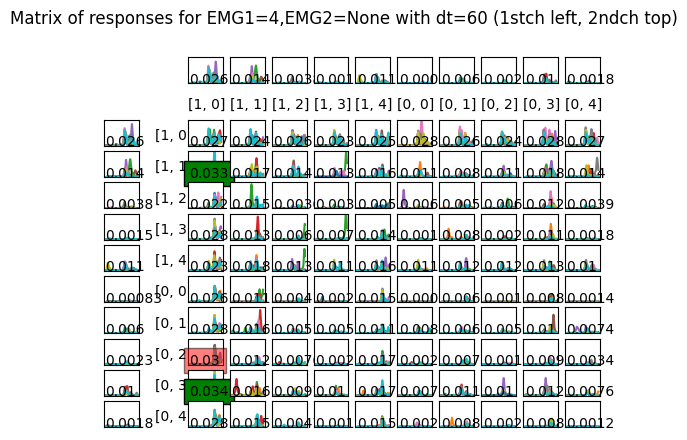

In [33]:

# 2D dataset
#-------------------------------------------------
# Create 2D dataset
X_2D, Y_2D, Xmean_2D, Ymean_2D = make_dataset_2d(trainsC, emg=emg, syn=None, dt=dt, n=None)
print('Shape X', X_2D.shape)
print('Shape Y', Y_2D.shape)
print('Shape Xmean', Xmean_2D.shape)
print('Shape Ymean', Ymean_2D.shape)

ground_truth_max_2D = np.max(Ymean_2D)
print('GT max: ', ground_truth_max_2D)
trainsC.plot_response_matrix(emg=emg, dt=dt)

test_x_2D = torch.tensor(Xmean_2D) 
#--------------------------------------------------

repetition:  0


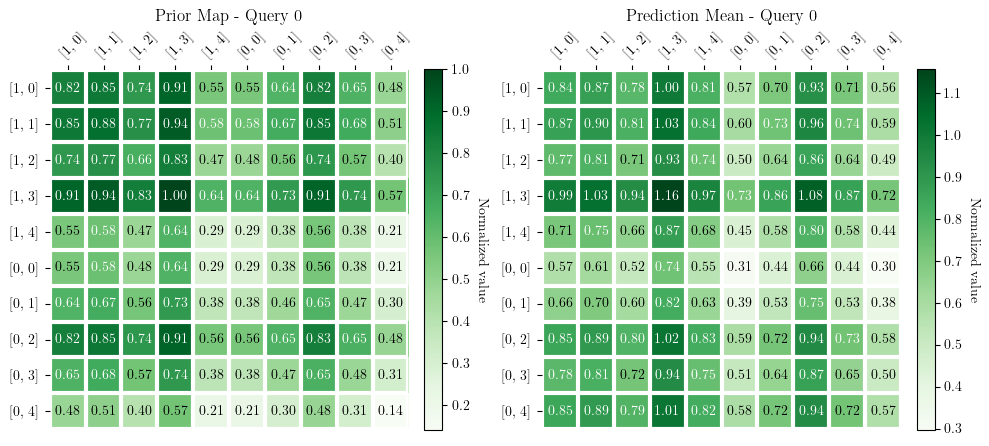

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)


Iter 1/10 - Loss: 1.242   lengthscale: 0.693   noise: 0.693
Iter 2/10 - Loss: 1.170   lengthscale: 0.744   noise: 0.644
Iter 3/10 - Loss: 1.098   lengthscale: 0.798   noise: 0.598
Iter 4/10 - Loss: 1.028   lengthscale: 0.854   noise: 0.554
Iter 5/10 - Loss: 0.959   lengthscale: 0.912   noise: 0.513
Iter 6/10 - Loss: 0.893   lengthscale: 0.971   noise: 0.473
Iter 7/10 - Loss: 0.828   lengthscale: 1.032   noise: 0.436
Iter 8/10 - Loss: 0.767   lengthscale: 1.093   noise: 0.402
Iter 9/10 - Loss: 0.708   lengthscale: 1.156   noise: 0.369
Iter 10/10 - Loss: 0.652   lengthscale: 1.218   noise: 0.339
Iter 1/10 - Loss: 0.593   lengthscale: 1.281   noise: 0.310
Iter 2/10 - Loss: 0.544   lengthscale: 1.354   noise: 0.284
Iter 3/10 - Loss: 0.498   lengthscale: 1.429   noise: 0.261
Iter 4/10 - Loss: 0.450   lengthscale: 1.506   noise: 0.238
Iter 5/10 - Loss: 0.400   lengthscale: 1.585   noise: 0.218
Iter 6/10 - Loss: 0.352   lengthscale: 1.665   noise: 0.199
Iter 7/10 - Loss: 0.303   lengthscale: 

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:167: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]


Iter 1/10 - Loss: 0.098   lengthscale: 2.085   noise: 0.125
Iter 2/10 - Loss: 0.052   lengthscale: 2.173   noise: 0.114
Iter 3/10 - Loss: -0.002   lengthscale: 2.262   noise: 0.103
Iter 4/10 - Loss: -0.051   lengthscale: 2.352   noise: 0.094
Iter 5/10 - Loss: -0.099   lengthscale: 2.442   noise: 0.085
Iter 6/10 - Loss: -0.150   lengthscale: 2.533   noise: 0.078
Iter 7/10 - Loss: -0.201   lengthscale: 2.624   noise: 0.070
Iter 8/10 - Loss: -0.250   lengthscale: 2.715   noise: 0.064
Iter 9/10 - Loss: -0.299   lengthscale: 2.805   noise: 0.058
Iter 10/10 - Loss: -0.348   lengthscale: 2.896   noise: 0.053
Iter 1/10 - Loss: -0.409   lengthscale: 2.986   noise: 0.048
Iter 2/10 - Loss: -0.451   lengthscale: 3.081   noise: 0.043
Iter 3/10 - Loss: -0.506   lengthscale: 3.177   noise: 0.039
Iter 4/10 - Loss: -0.553   lengthscale: 3.272   noise: 0.036
Iter 5/10 - Loss: -0.599   lengthscale: 3.368   noise: 0.032
Iter 6/10 - Loss: -0.649   lengthscale: 3.463   noise: 0.029
Iter 7/10 - Loss: -0.698 

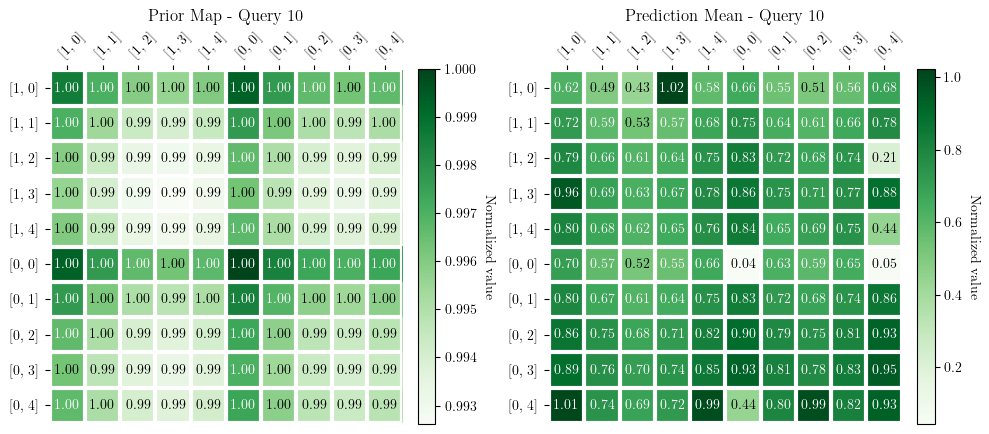

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844

Iter 1/10 - Loss: -1.845   lengthscale: 7.940   noise: 0.001
Iter 2/10 - Loss: -1.769   lengthscale: 8.040   noise: 0.001
Iter 3/10 - Loss: -1.848   lengthscale: 8.120   noise: 0.001
Iter 4/10 - Loss: -1.841   lengthscale: 8.200   noise: 0.001
Iter 5/10 - Loss: -1.812   lengthscale: 8.269   noise: 0.001
Iter 6/10 - Loss: -1.829   lengthscale: 8.329   noise: 0.001
Iter 7/10 - Loss: -1.852   lengthscale: 8.384   noise: 0.001
Iter 8/10 - Loss: -1.852   lengthscale: 8.438   noise: 0.001
Iter 9/10 - Loss: -1.837   lengthscale: 8.497   noise: 0.001
Iter 10/10 - Loss: -1.834   lengthscale: 8.564   noise: 0.001
Iter 1/10 - Loss: -1.882   lengthscale: 8.638   noise: 0.001
Iter 2/10 - Loss: -1.811   lengthscale: 8.738   noise: 0.001
Iter 3/10 - Loss: -1.885   lengthscale: 8.804   noise: 0.001
Iter 4/10 - Loss: -1.879   lengthscale: 8.862   noise: 0.001
Iter 5/10 - Loss: -1.853   lengthscale: 8.937   noise: 0.001
Iter 6/10 - Loss: -1.867   lengthscale: 9.019   noise: 0.001
Iter 7/10 - Loss: -1.88

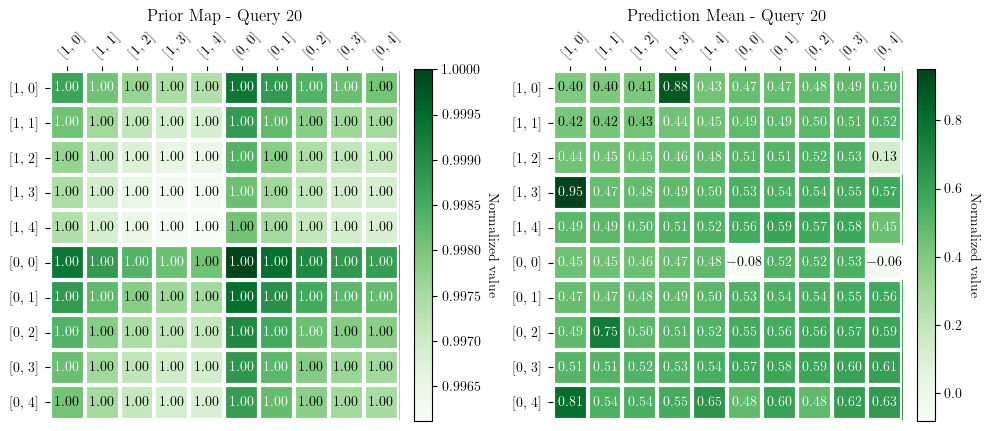

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844

Iter 1/10 - Loss: -2.129   lengthscale: 15.494   noise: 0.001
Iter 2/10 - Loss: -2.084   lengthscale: 15.594   noise: 0.001
Iter 3/10 - Loss: -2.131   lengthscale: 15.678   noise: 0.001
Iter 4/10 - Loss: -2.127   lengthscale: 15.764   noise: 0.001
Iter 5/10 - Loss: -2.109   lengthscale: 15.841   noise: 0.001
Iter 6/10 - Loss: -2.119   lengthscale: 15.909   noise: 0.001
Iter 7/10 - Loss: -2.132   lengthscale: 15.971   noise: 0.001
Iter 8/10 - Loss: -2.133   lengthscale: 16.035   noise: 0.001
Iter 9/10 - Loss: -2.124   lengthscale: 16.105   noise: 0.001
Iter 10/10 - Loss: -2.121   lengthscale: 16.182   noise: 0.001
Iter 1/10 - Loss: -2.147   lengthscale: 16.264   noise: 0.001
Iter 2/10 - Loss: -2.112   lengthscale: 16.364   noise: 0.001
Iter 3/10 - Loss: -2.150   lengthscale: 16.414   noise: 0.001
Iter 4/10 - Loss: -2.148   lengthscale: 16.469   noise: 0.001
Iter 5/10 - Loss: -2.133   lengthscale: 16.541   noise: 0.001
Iter 6/10 - Loss: -2.140   lengthscale: 16.623   noise: 0.001
Iter 7/

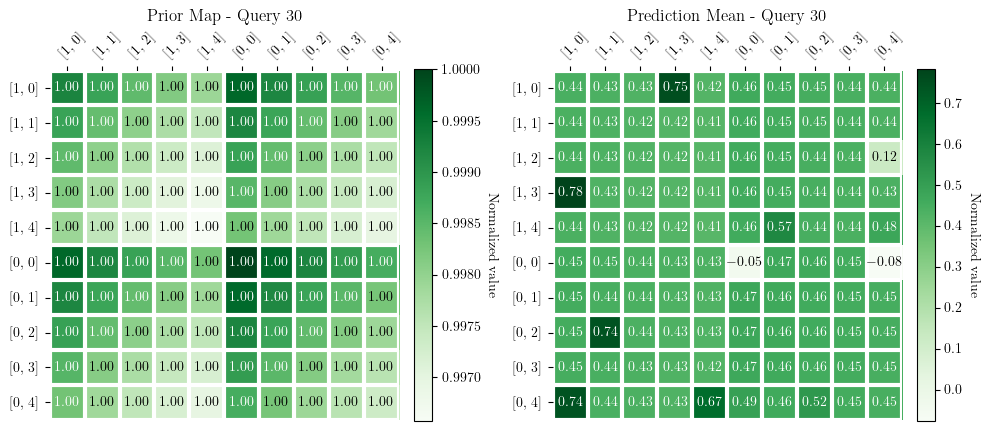

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844

Iter 1/10 - Loss: -2.309   lengthscale: 23.708   noise: 0.001
Iter 2/10 - Loss: -2.281   lengthscale: 23.808   noise: 0.001
Iter 3/10 - Loss: -2.311   lengthscale: 23.898   noise: 0.001
Iter 4/10 - Loss: -2.309   lengthscale: 23.990   noise: 0.001
Iter 5/10 - Loss: -2.298   lengthscale: 24.075   noise: 0.001
Iter 6/10 - Loss: -2.303   lengthscale: 24.150   noise: 0.001
Iter 7/10 - Loss: -2.312   lengthscale: 24.223   noise: 0.001
Iter 8/10 - Loss: -2.312   lengthscale: 24.297   noise: 0.001
Iter 9/10 - Loss: -2.307   lengthscale: 24.377   noise: 0.001
Iter 10/10 - Loss: -2.305   lengthscale: 24.462   noise: 0.001
Iter 1/10 - Loss: -2.323   lengthscale: 24.552   noise: 0.001
Iter 2/10 - Loss: -2.298   lengthscale: 24.652   noise: 0.000
Iter 3/10 - Loss: -2.325   lengthscale: 24.712   noise: 0.001
Iter 4/10 - Loss: -2.324   lengthscale: 24.778   noise: 0.001
Iter 5/10 - Loss: -2.313   lengthscale: 24.857   noise: 0.001
Iter 6/10 - Loss: -2.318   lengthscale: 24.944   noise: 0.001
Iter 7/

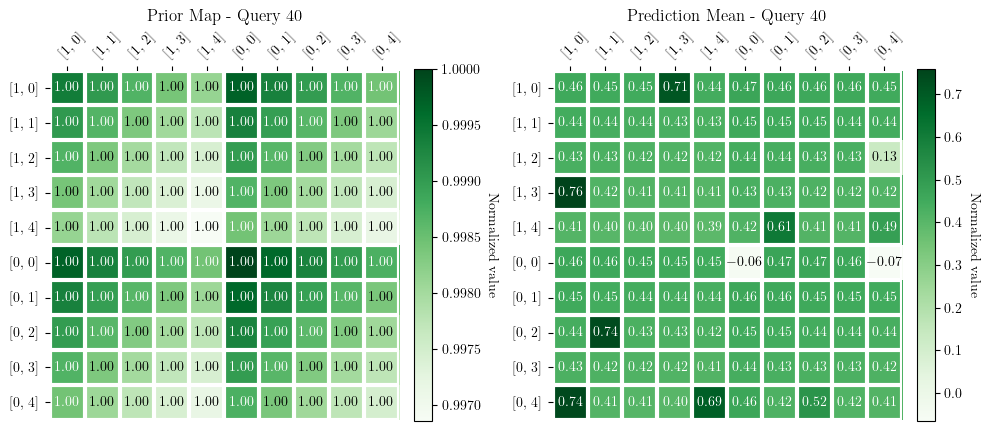

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)


Iter 1/10 - Loss: -2.424   lengthscale: 31.734   noise: 0.000
Iter 2/10 - Loss: -2.405   lengthscale: 31.834   noise: 0.000
Iter 3/10 - Loss: -2.426   lengthscale: 31.923   noise: 0.000
Iter 4/10 - Loss: -2.424   lengthscale: 32.014   noise: 0.000
Iter 5/10 - Loss: -2.417   lengthscale: 32.092   noise: 0.000
Iter 6/10 - Loss: -2.421   lengthscale: 32.158   noise: 0.000
Iter 7/10 - Loss: -2.427   lengthscale: 32.220   noise: 0.000
Iter 8/10 - Loss: -2.427   lengthscale: 32.284   noise: 0.000
Iter 9/10 - Loss: -2.423   lengthscale: 32.357   noise: 0.000
Iter 10/10 - Loss: -2.422   lengthscale: 32.436   noise: 0.000


C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:167: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]


Iter 1/10 - Loss: -2.434   lengthscale: 32.521   noise: 0.000
Iter 2/10 - Loss: -2.416   lengthscale: 32.621   noise: 0.000
Iter 3/10 - Loss: -2.435   lengthscale: 32.677   noise: 0.000
Iter 4/10 - Loss: -2.434   lengthscale: 32.740   noise: 0.000
Iter 5/10 - Loss: -2.427   lengthscale: 32.818   noise: 0.000
Iter 6/10 - Loss: -2.431   lengthscale: 32.903   noise: 0.000
Iter 7/10 - Loss: -2.437   lengthscale: 32.992   noise: 0.000
Iter 8/10 - Loss: -2.437   lengthscale: 33.084   noise: 0.000
Iter 9/10 - Loss: -2.433   lengthscale: 33.173   noise: 0.000
Iter 10/10 - Loss: -2.432   lengthscale: 33.257   noise: 0.000
Iter 1/10 - Loss: -2.444   lengthscale: 33.336   noise: 0.000
Iter 2/10 - Loss: -2.421   lengthscale: 33.436   noise: 0.000
Iter 3/10 - Loss: -2.444   lengthscale: 33.524   noise: 0.000
Iter 4/10 - Loss: -2.442   lengthscale: 33.615   noise: 0.000
Iter 5/10 - Loss: -2.433   lengthscale: 33.697   noise: 0.000
Iter 6/10 - Loss: -2.438   lengthscale: 33.766   noise: 0.000
Iter 7/

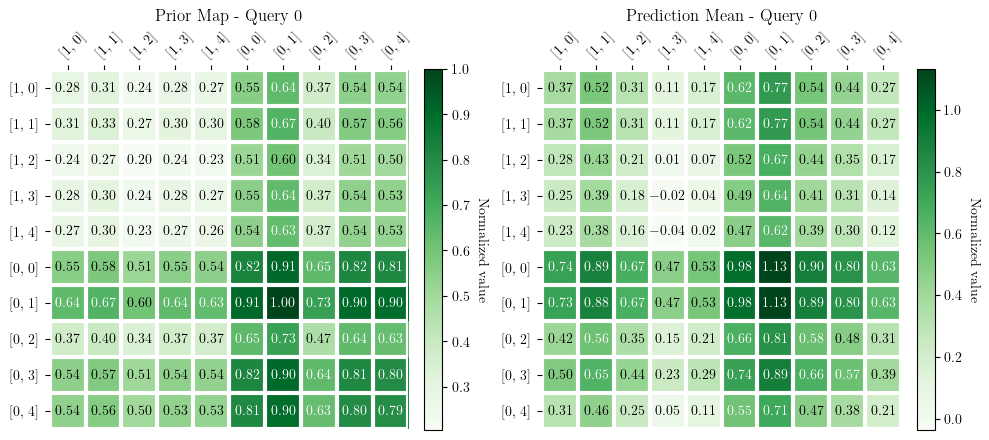

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844

Iter 1/10 - Loss: 1.214   lengthscale: 0.693   noise: 0.693
Iter 2/10 - Loss: 1.145   lengthscale: 0.744   noise: 0.644
Iter 3/10 - Loss: 1.076   lengthscale: 0.798   noise: 0.598
Iter 4/10 - Loss: 1.008   lengthscale: 0.854   noise: 0.554
Iter 5/10 - Loss: 0.941   lengthscale: 0.912   noise: 0.513
Iter 6/10 - Loss: 0.875   lengthscale: 0.971   noise: 0.473
Iter 7/10 - Loss: 0.812   lengthscale: 1.032   noise: 0.436
Iter 8/10 - Loss: 0.751   lengthscale: 1.094   noise: 0.402
Iter 9/10 - Loss: 0.692   lengthscale: 1.156   noise: 0.369
Iter 10/10 - Loss: 0.637   lengthscale: 1.219   noise: 0.339
Iter 1/10 - Loss: 0.601   lengthscale: 1.283   noise: 0.310
Iter 2/10 - Loss: 0.550   lengthscale: 1.356   noise: 0.284
Iter 3/10 - Loss: 0.505   lengthscale: 1.431   noise: 0.261
Iter 4/10 - Loss: 0.459   lengthscale: 1.508   noise: 0.238
Iter 5/10 - Loss: 0.411   lengthscale: 1.587   noise: 0.218
Iter 6/10 - Loss: 0.362   lengthscale: 1.667   noise: 0.199
Iter 7/10 - Loss: 0.314   lengthscale: 

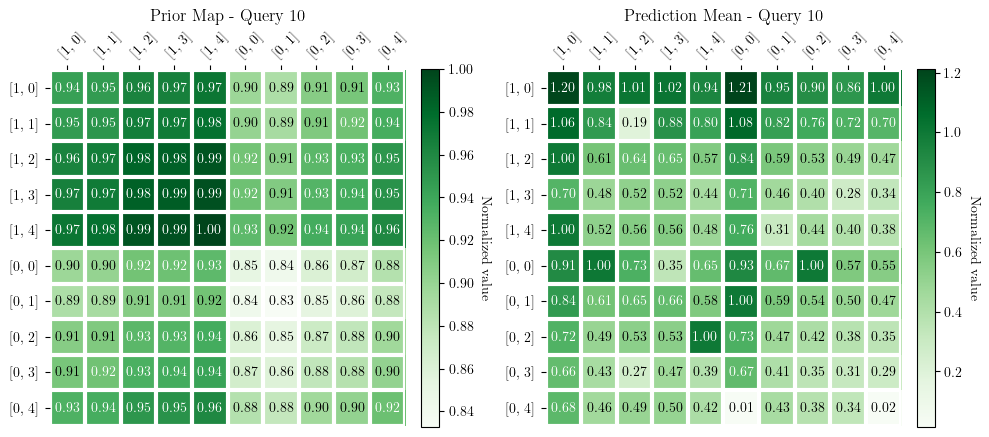

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844

Iter 1/10 - Loss: -0.906   lengthscale: 1.645   noise: 0.006
Iter 2/10 - Loss: -0.893   lengthscale: 1.566   noise: 0.006
Iter 3/10 - Loss: -0.909   lengthscale: 1.494   noise: 0.005
Iter 4/10 - Loss: -0.906   lengthscale: 1.424   noise: 0.005
Iter 5/10 - Loss: -0.901   lengthscale: 1.446   noise: 0.005
Iter 6/10 - Loss: -0.906   lengthscale: 1.489   noise: 0.006
Iter 7/10 - Loss: -0.911   lengthscale: 1.534   noise: 0.006
Iter 8/10 - Loss: -0.909   lengthscale: 1.555   noise: 0.006
Iter 9/10 - Loss: -0.906   lengthscale: 1.551   noise: 0.006
Iter 10/10 - Loss: -0.906   lengthscale: 1.532   noise: 0.006
Iter 1/10 - Loss: -0.949   lengthscale: 1.501   noise: 0.006
Iter 2/10 - Loss: -0.930   lengthscale: 1.424   noise: 0.005
Iter 3/10 - Loss: -0.951   lengthscale: 1.467   noise: 0.005
Iter 4/10 - Loss: -0.947   lengthscale: 1.478   noise: 0.005
Iter 5/10 - Loss: -0.940   lengthscale: 1.471   noise: 0.005
Iter 6/10 - Loss: -0.944   lengthscale: 1.468   noise: 0.005
Iter 7/10 - Loss: -0.95

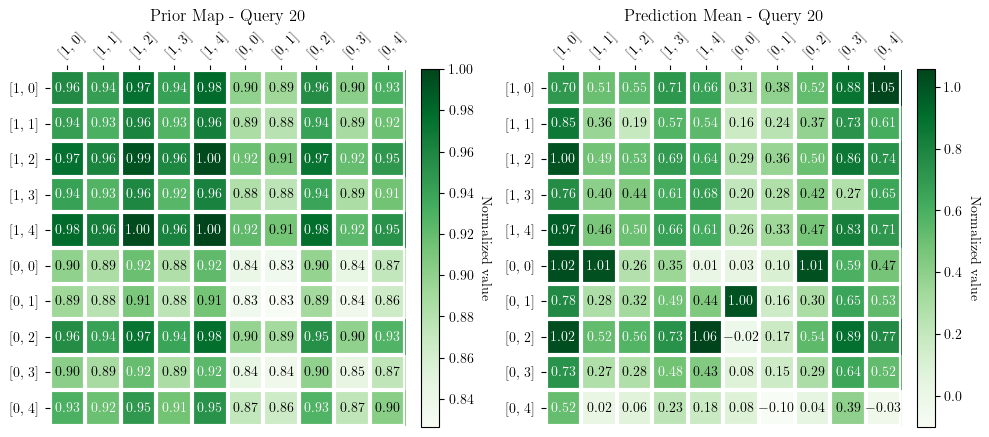

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844

Iter 1/10 - Loss: -0.937   lengthscale: 0.531   noise: 0.006
Iter 2/10 - Loss: -0.938   lengthscale: 0.573   noise: 0.005
Iter 3/10 - Loss: -0.941   lengthscale: 0.591   noise: 0.006
Iter 4/10 - Loss: -0.954   lengthscale: 0.587   noise: 0.006
Iter 5/10 - Loss: -0.950   lengthscale: 0.567   noise: 0.006
Iter 6/10 - Loss: -0.945   lengthscale: 0.545   noise: 0.006
Iter 7/10 - Loss: -0.952   lengthscale: 0.528   noise: 0.006
Iter 8/10 - Loss: -0.958   lengthscale: 0.508   noise: 0.006
Iter 9/10 - Loss: -0.953   lengthscale: 0.483   noise: 0.006
Iter 10/10 - Loss: -0.951   lengthscale: 0.458   noise: 0.006
Iter 1/10 - Loss: -0.980   lengthscale: 0.432   noise: 0.006
Iter 2/10 - Loss: -0.907   lengthscale: 0.398   noise: 0.005
Iter 3/10 - Loss: -0.976   lengthscale: 0.419   noise: 0.005
Iter 4/10 - Loss: -0.967   lengthscale: 0.435   noise: 0.006
Iter 5/10 - Loss: -0.943   lengthscale: 0.448   noise: 0.006
Iter 6/10 - Loss: -0.949   lengthscale: 0.466   noise: 0.006
Iter 7/10 - Loss: -0.96

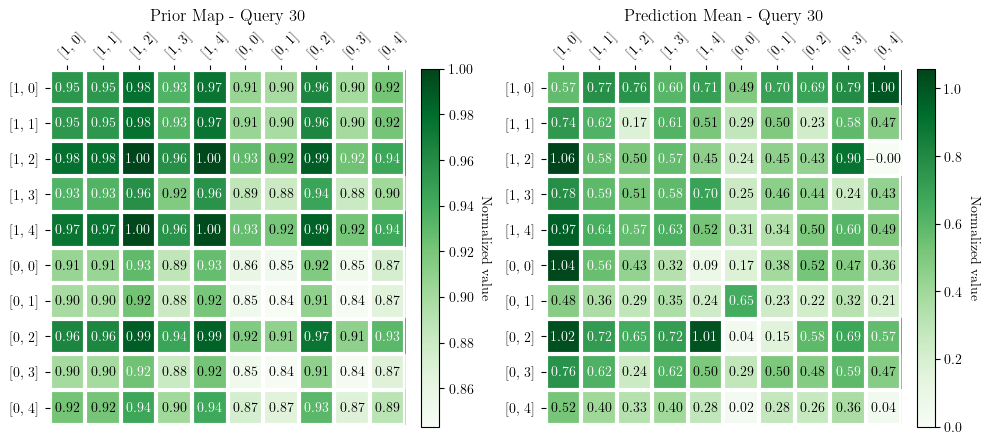

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)


Iter 1/10 - Loss: -0.993   lengthscale: 0.553   noise: 0.006
Iter 2/10 - Loss: -0.995   lengthscale: 0.596   noise: 0.006
Iter 3/10 - Loss: -0.996   lengthscale: 0.641   noise: 0.006
Iter 4/10 - Loss: -1.005   lengthscale: 0.657   noise: 0.006
Iter 5/10 - Loss: -1.003   lengthscale: 0.634   noise: 0.005
Iter 6/10 - Loss: -1.000   lengthscale: 0.604   noise: 0.005
Iter 7/10 - Loss: -1.005   lengthscale: 0.571   noise: 0.006
Iter 8/10 - Loss: -1.009   lengthscale: 0.538   noise: 0.006
Iter 9/10 - Loss: -1.007   lengthscale: 0.504   noise: 0.006
Iter 10/10 - Loss: -1.005   lengthscale: 0.473   noise: 0.006


C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:167: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]


Iter 1/10 - Loss: -1.021   lengthscale: 0.445   noise: 0.006
Iter 2/10 - Loss: -0.961   lengthscale: 0.410   noise: 0.005
Iter 3/10 - Loss: -1.020   lengthscale: 0.434   noise: 0.005
Iter 4/10 - Loss: -1.011   lengthscale: 0.449   noise: 0.006
Iter 5/10 - Loss: -0.992   lengthscale: 0.466   noise: 0.006
Iter 6/10 - Loss: -1.000   lengthscale: 0.488   noise: 0.006
Iter 7/10 - Loss: -1.014   lengthscale: 0.515   noise: 0.006
Iter 8/10 - Loss: -1.020   lengthscale: 0.539   noise: 0.006
Iter 9/10 - Loss: -1.016   lengthscale: 0.557   noise: 0.005
Iter 10/10 - Loss: -1.009   lengthscale: 0.571   noise: 0.005
Iter 1/10 - Loss: -0.997   lengthscale: 0.583   noise: 0.005
Iter 2/10 - Loss: -0.996   lengthscale: 0.540   noise: 0.006
Iter 3/10 - Loss: -0.998   lengthscale: 0.568   noise: 0.006
Iter 4/10 - Loss: -1.008   lengthscale: 0.602   noise: 0.006
Iter 5/10 - Loss: -1.005   lengthscale: 0.602   noise: 0.006
Iter 6/10 - Loss: -1.001   lengthscale: 0.587   noise: 0.006
Iter 7/10 - Loss: -1.00

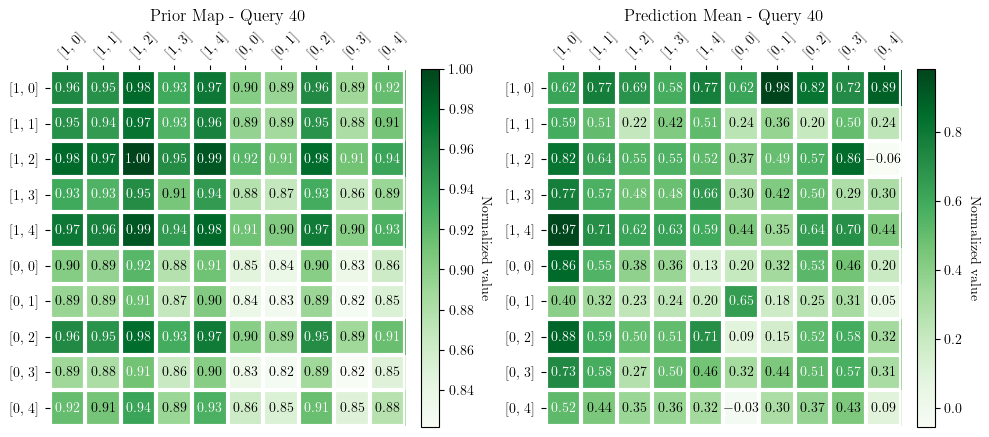

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)


Iter 1/10 - Loss: -1.008   lengthscale: 0.549   noise: 0.005
Iter 2/10 - Loss: -1.010   lengthscale: 0.593   noise: 0.006
Iter 3/10 - Loss: -1.010   lengthscale: 0.604   noise: 0.006
Iter 4/10 - Loss: -1.018   lengthscale: 0.594   noise: 0.006
Iter 5/10 - Loss: -1.016   lengthscale: 0.569   noise: 0.006
Iter 6/10 - Loss: -1.013   lengthscale: 0.543   noise: 0.006
Iter 7/10 - Loss: -1.017   lengthscale: 0.520   noise: 0.006
Iter 8/10 - Loss: -1.020   lengthscale: 0.496   noise: 0.006
Iter 9/10 - Loss: -1.017   lengthscale: 0.469   noise: 0.006
Iter 10/10 - Loss: -1.017   lengthscale: 0.442   noise: 0.006


C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:167: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]


Iter 1/10 - Loss: -1.011   lengthscale: 0.417   noise: 0.006
Iter 2/10 - Loss: -0.964   lengthscale: 0.384   noise: 0.005
Iter 3/10 - Loss: -1.010   lengthscale: 0.406   noise: 0.006
Iter 4/10 - Loss: -1.003   lengthscale: 0.425   noise: 0.006
Iter 5/10 - Loss: -0.988   lengthscale: 0.442   noise: 0.006
Iter 6/10 - Loss: -0.994   lengthscale: 0.465   noise: 0.006
Iter 7/10 - Loss: -1.005   lengthscale: 0.490   noise: 0.006
Iter 8/10 - Loss: -1.010   lengthscale: 0.514   noise: 0.006
Iter 9/10 - Loss: -1.008   lengthscale: 0.534   noise: 0.006
Iter 10/10 - Loss: -1.003   lengthscale: 0.551   noise: 0.006
Iter 1/10 - Loss: -1.011   lengthscale: 0.569   noise: 0.006
Iter 2/10 - Loss: -1.012   lengthscale: 0.614   noise: 0.006
Iter 3/10 - Loss: -1.014   lengthscale: 0.645   noise: 0.006
Iter 4/10 - Loss: -1.020   lengthscale: 0.654   noise: 0.006
Iter 5/10 - Loss: -1.018   lengthscale: 0.639   noise: 0.006
Iter 6/10 - Loss: -1.015   lengthscale: 0.618   noise: 0.006
Iter 7/10 - Loss: -1.01

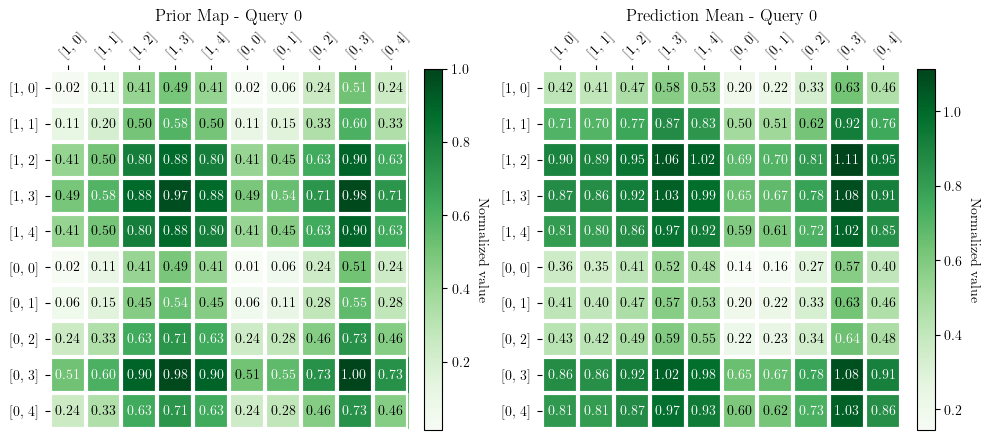

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844

Iter 1/10 - Loss: 1.189   lengthscale: 0.693   noise: 0.693
Iter 2/10 - Loss: 1.120   lengthscale: 0.744   noise: 0.644
Iter 3/10 - Loss: 1.052   lengthscale: 0.798   noise: 0.598
Iter 4/10 - Loss: 0.985   lengthscale: 0.854   noise: 0.554
Iter 5/10 - Loss: 0.920   lengthscale: 0.911   noise: 0.513
Iter 6/10 - Loss: 0.856   lengthscale: 0.970   noise: 0.474
Iter 7/10 - Loss: 0.795   lengthscale: 1.030   noise: 0.437
Iter 8/10 - Loss: 0.735   lengthscale: 1.091   noise: 0.402
Iter 9/10 - Loss: 0.678   lengthscale: 1.153   noise: 0.369
Iter 10/10 - Loss: 0.623   lengthscale: 1.215   noise: 0.339
Iter 1/10 - Loss: 0.580   lengthscale: 1.278   noise: 0.310
Iter 2/10 - Loss: 0.532   lengthscale: 1.351   noise: 0.285
Iter 3/10 - Loss: 0.486   lengthscale: 1.426   noise: 0.261
Iter 4/10 - Loss: 0.438   lengthscale: 1.503   noise: 0.239
Iter 5/10 - Loss: 0.389   lengthscale: 1.581   noise: 0.218
Iter 6/10 - Loss: 0.341   lengthscale: 1.661   noise: 0.199
Iter 7/10 - Loss: 0.293   lengthscale: 

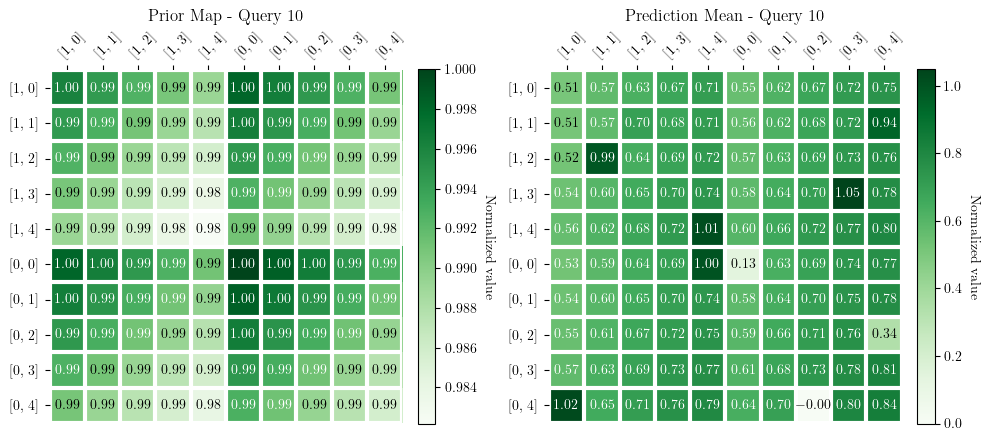

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844

Iter 1/10 - Loss: -2.517   lengthscale: 9.408   noise: 0.000
Iter 2/10 - Loss: -2.455   lengthscale: 9.508   noise: 0.000
Iter 3/10 - Loss: -2.520   lengthscale: 9.608   noise: 0.000
Iter 4/10 - Loss: -2.517   lengthscale: 9.702   noise: 0.000
Iter 5/10 - Loss: -2.492   lengthscale: 9.798   noise: 0.000
Iter 6/10 - Loss: -2.504   lengthscale: 9.895   noise: 0.000
Iter 7/10 - Loss: -2.524   lengthscale: 9.994   noise: 0.000
Iter 8/10 - Loss: -2.525   lengthscale: 10.089   noise: 0.000
Iter 9/10 - Loss: -2.513   lengthscale: 10.180   noise: 0.000
Iter 10/10 - Loss: -2.509   lengthscale: 10.268   noise: 0.000
Iter 1/10 - Loss: -2.554   lengthscale: 10.352   noise: 0.000
Iter 2/10 - Loss: -2.496   lengthscale: 10.452   noise: 0.000
Iter 3/10 - Loss: -2.558   lengthscale: 10.544   noise: 0.000
Iter 4/10 - Loss: -2.553   lengthscale: 10.633   noise: 0.000
Iter 5/10 - Loss: -2.530   lengthscale: 10.713   noise: 0.000
Iter 6/10 - Loss: -2.542   lengthscale: 10.791   noise: 0.000
Iter 7/10 - Lo

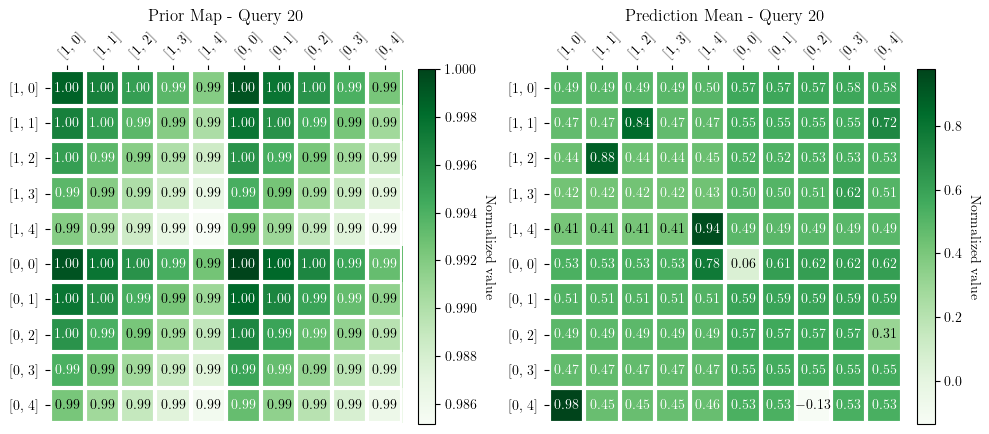

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)


Iter 1/10 - Loss: -2.714   lengthscale: 12.892   noise: 0.000
Iter 2/10 - Loss: -2.596   lengthscale: 12.792   noise: 0.000
Iter 3/10 - Loss: -2.707   lengthscale: 12.741   noise: 0.000
Iter 4/10 - Loss: -2.692   lengthscale: 12.669   noise: 0.000
Iter 5/10 - Loss: -2.653   lengthscale: 12.587   noise: 0.000
Iter 6/10 - Loss: -2.663   lengthscale: 12.508   noise: 0.000
Iter 7/10 - Loss: -2.693   lengthscale: 12.432   noise: 0.000
Iter 8/10 - Loss: -2.711   lengthscale: 12.360   noise: 0.000
Iter 9/10 - Loss: -2.709   lengthscale: 12.291   noise: 0.000
Iter 10/10 - Loss: -2.697   lengthscale: 12.233   noise: 0.000


C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:167: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]


Iter 1/10 - Loss: -2.701   lengthscale: 12.194   noise: 0.000
Iter 2/10 - Loss: -2.710   lengthscale: 12.294   noise: 0.000
Iter 3/10 - Loss: -2.703   lengthscale: 12.392   noise: 0.000
Iter 4/10 - Loss: -2.717   lengthscale: 12.491   noise: 0.000
Iter 5/10 - Loss: -2.720   lengthscale: 12.590   noise: 0.000
Iter 6/10 - Loss: -2.713   lengthscale: 12.690   noise: 0.000
Iter 7/10 - Loss: -2.712   lengthscale: 12.791   noise: 0.000
Iter 8/10 - Loss: -2.718   lengthscale: 12.892   noise: 0.000
Iter 9/10 - Loss: -2.723   lengthscale: 12.989   noise: 0.000
Iter 10/10 - Loss: -2.721   lengthscale: 13.077   noise: 0.000
Iter 1/10 - Loss: -2.732   lengthscale: 13.153   noise: 0.000
Iter 2/10 - Loss: -2.701   lengthscale: 13.053   noise: 0.000
Iter 3/10 - Loss: -2.734   lengthscale: 12.962   noise: 0.000
Iter 4/10 - Loss: -2.733   lengthscale: 12.867   noise: 0.000
Iter 5/10 - Loss: -2.721   lengthscale: 12.772   noise: 0.000
Iter 6/10 - Loss: -2.726   lengthscale: 12.690   noise: 0.000
Iter 7/

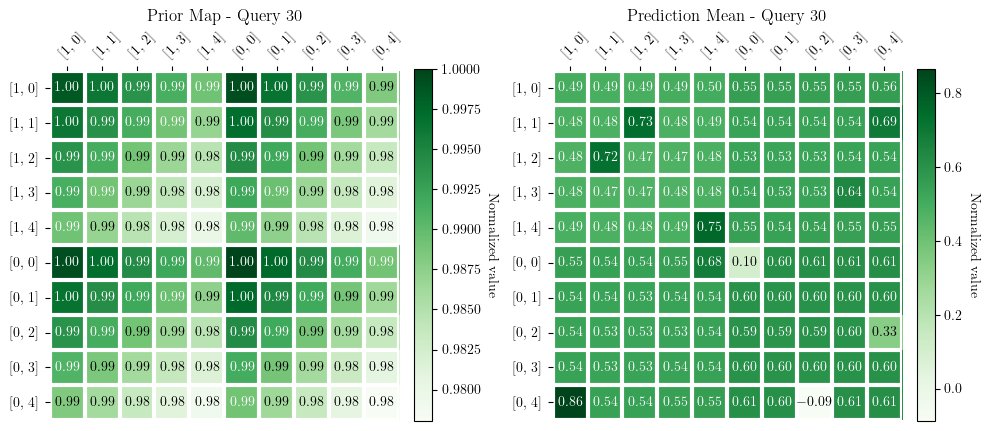

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)


Iter 1/10 - Loss: -2.791   lengthscale: 9.809   noise: 0.000
Iter 2/10 - Loss: -2.762   lengthscale: 9.709   noise: 0.000
Iter 3/10 - Loss: -2.791   lengthscale: 9.638   noise: 0.000
Iter 4/10 - Loss: -2.788   lengthscale: 9.555   noise: 0.000
Iter 5/10 - Loss: -2.778   lengthscale: 9.466   noise: 0.000
Iter 6/10 - Loss: -2.783   lengthscale: 9.377   noise: 0.000
Iter 7/10 - Loss: -2.792   lengthscale: 9.286   noise: 0.000
Iter 8/10 - Loss: -2.793   lengthscale: 9.192   noise: 0.000
Iter 9/10 - Loss: -2.788   lengthscale: 9.097   noise: 0.000
Iter 10/10 - Loss: -2.785   lengthscale: 9.003   noise: 0.000


C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:167: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]


Iter 1/10 - Loss: -2.794   lengthscale: 8.909   noise: 0.000
Iter 2/10 - Loss: -2.780   lengthscale: 8.809   noise: 0.000
Iter 3/10 - Loss: -2.797   lengthscale: 8.710   noise: 0.000
Iter 4/10 - Loss: -2.798   lengthscale: 8.611   noise: 0.000
Iter 5/10 - Loss: -2.791   lengthscale: 8.511   noise: 0.000
Iter 6/10 - Loss: -2.794   lengthscale: 8.413   noise: 0.000
Iter 7/10 - Loss: -2.800   lengthscale: 8.315   noise: 0.000
Iter 8/10 - Loss: -2.800   lengthscale: 8.216   noise: 0.000
Iter 9/10 - Loss: -2.796   lengthscale: 8.116   noise: 0.000
Iter 10/10 - Loss: -2.796   lengthscale: 8.014   noise: 0.000
Iter 1/10 - Loss: -2.805   lengthscale: 7.912   noise: 0.000
Iter 2/10 - Loss: -2.766   lengthscale: 7.812   noise: 0.000
Iter 3/10 - Loss: -2.805   lengthscale: 7.767   noise: 0.000
Iter 4/10 - Loss: -2.799   lengthscale: 7.698   noise: 0.000
Iter 5/10 - Loss: -2.786   lengthscale: 7.619   noise: 0.000
Iter 6/10 - Loss: -2.792   lengthscale: 7.538   noise: 0.000
Iter 7/10 - Loss: -2.80

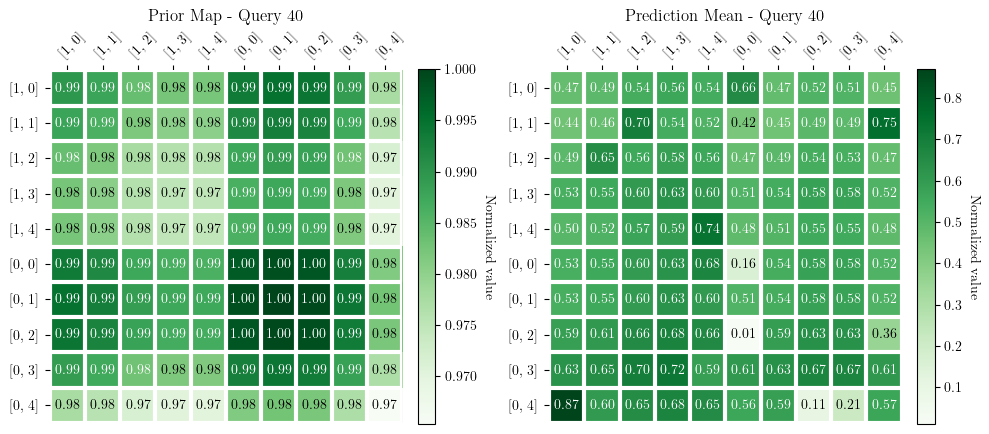

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)


Iter 1/10 - Loss: -2.758   lengthscale: 2.436   noise: 0.000
Iter 2/10 - Loss: -2.716   lengthscale: 2.345   noise: 0.000
Iter 3/10 - Loss: -2.758   lengthscale: 2.396   noise: 0.000
Iter 4/10 - Loss: -2.753   lengthscale: 2.431   noise: 0.000
Iter 5/10 - Loss: -2.738   lengthscale: 2.447   noise: 0.000
Iter 6/10 - Loss: -2.746   lengthscale: 2.456   noise: 0.000
Iter 7/10 - Loss: -2.758   lengthscale: 2.457   noise: 0.000
Iter 8/10 - Loss: -2.760   lengthscale: 2.448   noise: 0.000
Iter 9/10 - Loss: -2.752   lengthscale: 2.436   noise: 0.000
Iter 10/10 - Loss: -2.749   lengthscale: 2.431   noise: 0.000


C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:167: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]


Iter 1/10 - Loss: -2.762   lengthscale: 2.435   noise: 0.000
Iter 2/10 - Loss: -2.738   lengthscale: 2.527   noise: 0.000
Iter 3/10 - Loss: -2.765   lengthscale: 2.479   noise: 0.000
Iter 4/10 - Loss: -2.766   lengthscale: 2.410   noise: 0.000
Iter 5/10 - Loss: -2.755   lengthscale: 2.350   noise: 0.000
Iter 6/10 - Loss: -2.760   lengthscale: 2.342   noise: 0.000
Iter 7/10 - Loss: -2.769   lengthscale: 2.356   noise: 0.000
Iter 8/10 - Loss: -2.769   lengthscale: 2.368   noise: 0.000
Iter 9/10 - Loss: -2.763   lengthscale: 2.369   noise: 0.000
Iter 10/10 - Loss: -2.764   lengthscale: 2.357   noise: 0.000
Iter 1/10 - Loss: -2.763   lengthscale: 2.332   noise: 0.000
Iter 2/10 - Loss: -2.703   lengthscale: 2.242   noise: 0.000
Iter 3/10 - Loss: -2.761   lengthscale: 2.276   noise: 0.000
Iter 4/10 - Loss: -2.753   lengthscale: 2.291   noise: 0.000
Iter 5/10 - Loss: -2.733   lengthscale: 2.289   noise: 0.000
Iter 6/10 - Loss: -2.742   lengthscale: 2.286   noise: 0.000
Iter 7/10 - Loss: -2.75

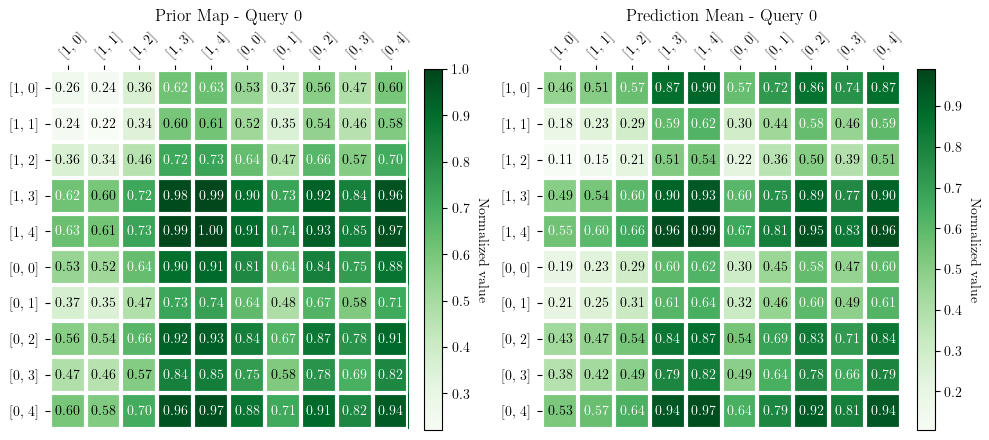

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844

Iter 1/10 - Loss: 1.260   lengthscale: 0.693   noise: 0.693
Iter 2/10 - Loss: 1.186   lengthscale: 0.744   noise: 0.644
Iter 3/10 - Loss: 1.112   lengthscale: 0.798   noise: 0.598
Iter 4/10 - Loss: 1.040   lengthscale: 0.854   noise: 0.554
Iter 5/10 - Loss: 0.969   lengthscale: 0.911   noise: 0.513
Iter 6/10 - Loss: 0.900   lengthscale: 0.971   noise: 0.473
Iter 7/10 - Loss: 0.834   lengthscale: 1.031   noise: 0.436
Iter 8/10 - Loss: 0.770   lengthscale: 1.093   noise: 0.401
Iter 9/10 - Loss: 0.710   lengthscale: 1.155   noise: 0.369
Iter 10/10 - Loss: 0.653   lengthscale: 1.217   noise: 0.338
Iter 1/10 - Loss: 0.592   lengthscale: 1.280   noise: 0.310
Iter 2/10 - Loss: 0.545   lengthscale: 1.353   noise: 0.284
Iter 3/10 - Loss: 0.497   lengthscale: 1.428   noise: 0.260
Iter 4/10 - Loss: 0.449   lengthscale: 1.505   noise: 0.238
Iter 5/10 - Loss: 0.401   lengthscale: 1.584   noise: 0.218
Iter 6/10 - Loss: 0.352   lengthscale: 1.664   noise: 0.199
Iter 7/10 - Loss: 0.302   lengthscale: 

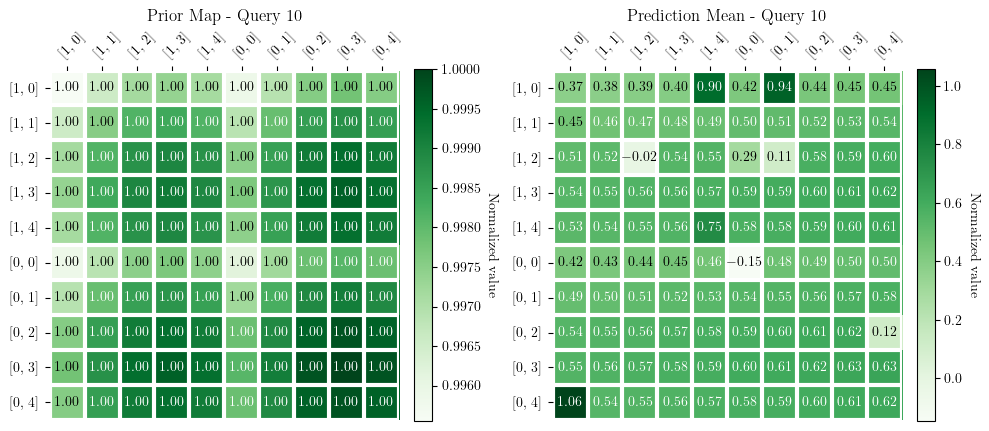

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844

Iter 1/10 - Loss: -2.805   lengthscale: 9.780   noise: 0.000
Iter 2/10 - Loss: -2.820   lengthscale: 9.880   noise: 0.000
Iter 3/10 - Loss: -2.810   lengthscale: 9.981   noise: 0.000
Iter 4/10 - Loss: -2.855   lengthscale: 10.081   noise: 0.000
Iter 5/10 - Loss: -2.859   lengthscale: 10.181   noise: 0.000
Iter 6/10 - Loss: -2.837   lengthscale: 10.280   noise: 0.000
Iter 7/10 - Loss: -2.837   lengthscale: 10.378   noise: 0.000
Iter 8/10 - Loss: -2.859   lengthscale: 10.476   noise: 0.000
Iter 9/10 - Loss: -2.872   lengthscale: 10.573   noise: 0.000
Iter 10/10 - Loss: -2.863   lengthscale: 10.670   noise: 0.000
Iter 1/10 - Loss: -2.889   lengthscale: 10.766   noise: 0.000
Iter 2/10 - Loss: -2.787   lengthscale: 10.866   noise: 0.000
Iter 3/10 - Loss: -2.897   lengthscale: 10.966   noise: 0.000
Iter 4/10 - Loss: -2.892   lengthscale: 11.065   noise: 0.000
Iter 5/10 - Loss: -2.851   lengthscale: 11.164   noise: 0.000
Iter 6/10 - Loss: -2.871   lengthscale: 11.264   noise: 0.000
Iter 7/10 

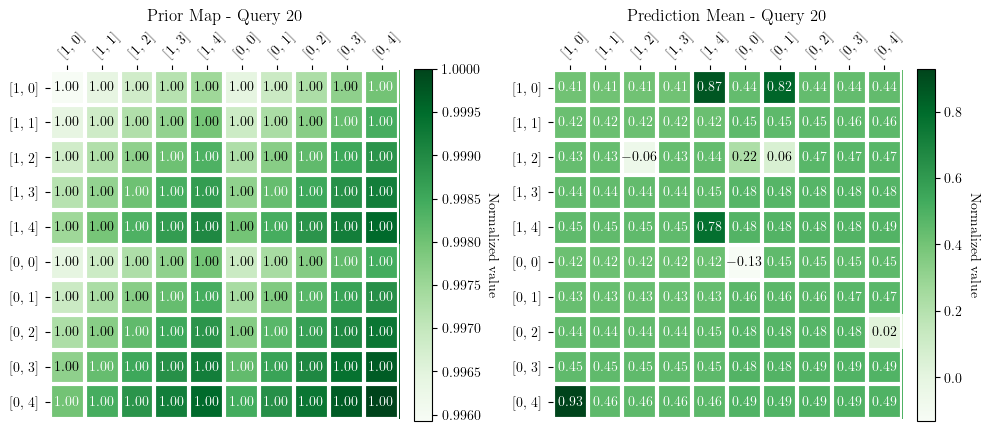

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844

Iter 1/10 - Loss: -3.117   lengthscale: 19.667   noise: 0.000
Iter 2/10 - Loss: -3.027   lengthscale: 19.767   noise: 0.000
Iter 3/10 - Loss: -3.116   lengthscale: 19.866   noise: 0.000
Iter 4/10 - Loss: -3.102   lengthscale: 19.964   noise: 0.000
Iter 5/10 - Loss: -3.072   lengthscale: 20.061   noise: 0.000
Iter 6/10 - Loss: -3.087   lengthscale: 20.158   noise: 0.000
Iter 7/10 - Loss: -3.112   lengthscale: 20.255   noise: 0.000
Iter 8/10 - Loss: -3.118   lengthscale: 20.352   noise: 0.000
Iter 9/10 - Loss: -3.107   lengthscale: 20.449   noise: 0.000
Iter 10/10 - Loss: -3.096   lengthscale: 20.547   noise: 0.000
Iter 1/10 - Loss: -3.118   lengthscale: 20.647   noise: 0.000
Iter 2/10 - Loss: -3.109   lengthscale: 20.747   noise: 0.000
Iter 3/10 - Loss: -3.118   lengthscale: 20.846   noise: 0.000
Iter 4/10 - Loss: -3.133   lengthscale: 20.945   noise: 0.000
Iter 5/10 - Loss: -3.127   lengthscale: 21.044   noise: 0.000
Iter 6/10 - Loss: -3.121   lengthscale: 21.144   noise: 0.000
Iter 7/

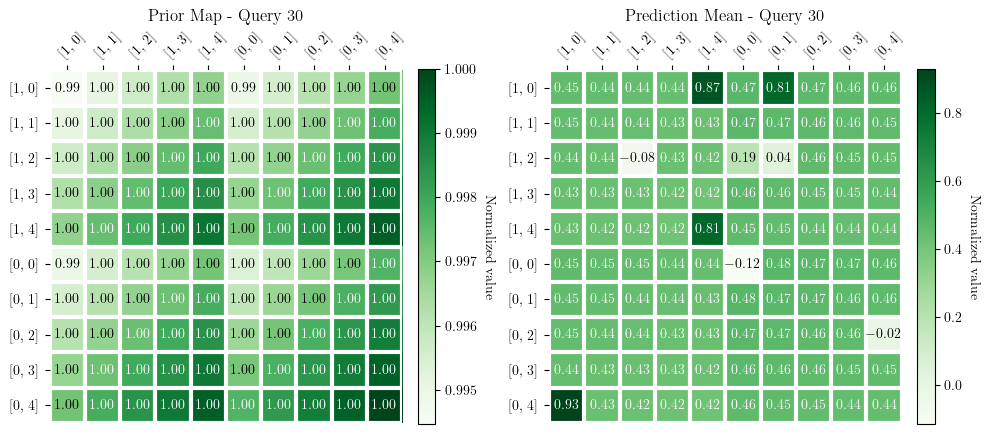

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)


Iter 1/10 - Loss: -3.231   lengthscale: 29.423   noise: 0.000
Iter 2/10 - Loss: -3.196   lengthscale: 29.523   noise: 0.000
Iter 3/10 - Loss: -3.232   lengthscale: 29.621   noise: 0.000
Iter 4/10 - Loss: -3.228   lengthscale: 29.718   noise: 0.000
Iter 5/10 - Loss: -3.215   lengthscale: 29.812   noise: 0.000
Iter 6/10 - Loss: -3.222   lengthscale: 29.905   noise: 0.000
Iter 7/10 - Loss: -3.232   lengthscale: 29.999   noise: 0.000
Iter 8/10 - Loss: -3.233   lengthscale: 30.095   noise: 0.000
Iter 9/10 - Loss: -3.227   lengthscale: 30.193   noise: 0.000
Iter 10/10 - Loss: -3.224   lengthscale: 30.293   noise: 0.000


C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:167: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]


Iter 1/10 - Loss: -3.237   lengthscale: 30.394   noise: 0.000
Iter 2/10 - Loss: -3.222   lengthscale: 30.494   noise: 0.000
Iter 3/10 - Loss: -3.240   lengthscale: 30.571   noise: 0.000
Iter 4/10 - Loss: -3.242   lengthscale: 30.651   noise: 0.000
Iter 5/10 - Loss: -3.234   lengthscale: 30.739   noise: 0.000
Iter 6/10 - Loss: -3.236   lengthscale: 30.831   noise: 0.000
Iter 7/10 - Loss: -3.242   lengthscale: 30.925   noise: 0.000
Iter 8/10 - Loss: -3.243   lengthscale: 31.021   noise: 0.000
Iter 9/10 - Loss: -3.239   lengthscale: 31.114   noise: 0.000
Iter 10/10 - Loss: -3.239   lengthscale: 31.203   noise: 0.000
Iter 1/10 - Loss: -3.253   lengthscale: 31.286   noise: 0.000
Iter 2/10 - Loss: -3.215   lengthscale: 31.186   noise: 0.000
Iter 3/10 - Loss: -3.252   lengthscale: 31.195   noise: 0.000
Iter 4/10 - Loss: -3.247   lengthscale: 31.185   noise: 0.000
Iter 5/10 - Loss: -3.234   lengthscale: 31.142   noise: 0.000
Iter 6/10 - Loss: -3.241   lengthscale: 31.090   noise: 0.000
Iter 7/

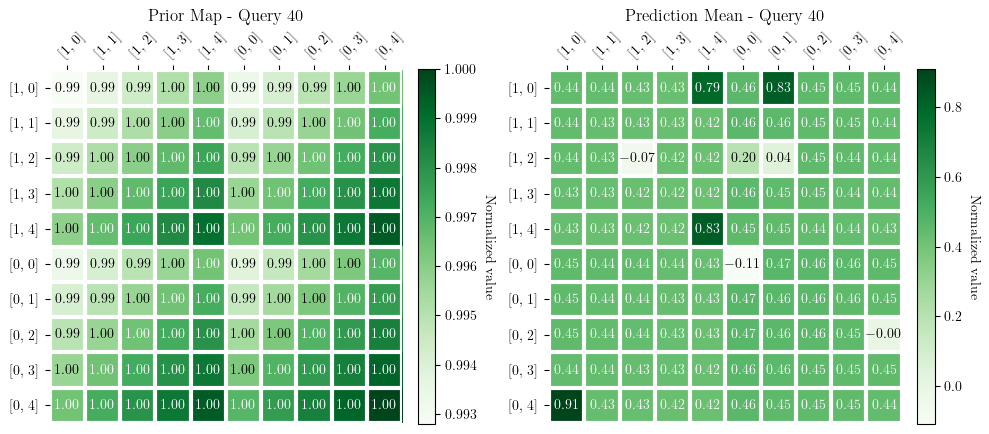

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)


Iter 1/10 - Loss: -3.311   lengthscale: 29.952   noise: 0.000
Iter 2/10 - Loss: -3.276   lengthscale: 29.852   noise: 0.000
Iter 3/10 - Loss: -3.309   lengthscale: 29.754   noise: 0.000
Iter 4/10 - Loss: -3.304   lengthscale: 29.654   noise: 0.000
Iter 5/10 - Loss: -3.293   lengthscale: 29.554   noise: 0.000
Iter 6/10 - Loss: -3.298   lengthscale: 29.455   noise: 0.000
Iter 7/10 - Loss: -3.307   lengthscale: 29.357   noise: 0.000
Iter 8/10 - Loss: -3.310   lengthscale: 29.264   noise: 0.000
Iter 9/10 - Loss: -3.307   lengthscale: 29.179   noise: 0.000
Iter 10/10 - Loss: -3.303   lengthscale: 29.105   noise: 0.000


C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:167: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]


Iter 1/10 - Loss: -3.308   lengthscale: 29.045   noise: 0.000
Iter 2/10 - Loss: -3.308   lengthscale: 29.145   noise: 0.000
Iter 3/10 - Loss: -3.308   lengthscale: 29.239   noise: 0.000
Iter 4/10 - Loss: -3.313   lengthscale: 29.333   noise: 0.000
Iter 5/10 - Loss: -3.313   lengthscale: 29.426   noise: 0.000
Iter 6/10 - Loss: -3.311   lengthscale: 29.521   noise: 0.000
Iter 7/10 - Loss: -3.311   lengthscale: 29.618   noise: 0.000
Iter 8/10 - Loss: -3.315   lengthscale: 29.712   noise: 0.000
Iter 9/10 - Loss: -3.315   lengthscale: 29.793   noise: 0.000
Iter 10/10 - Loss: -3.314   lengthscale: 29.844   noise: 0.000
Iter 1/10 - Loss: -3.319   lengthscale: 29.857   noise: 0.000
Iter 2/10 - Loss: -3.300   lengthscale: 29.757   noise: 0.000
Iter 3/10 - Loss: -3.320   lengthscale: 29.658   noise: 0.000
Iter 4/10 - Loss: -3.318   lengthscale: 29.558   noise: 0.000
Iter 5/10 - Loss: -3.311   lengthscale: 29.459   noise: 0.000
Iter 6/10 - Loss: -3.315   lengthscale: 29.360   noise: 0.000
Iter 7/

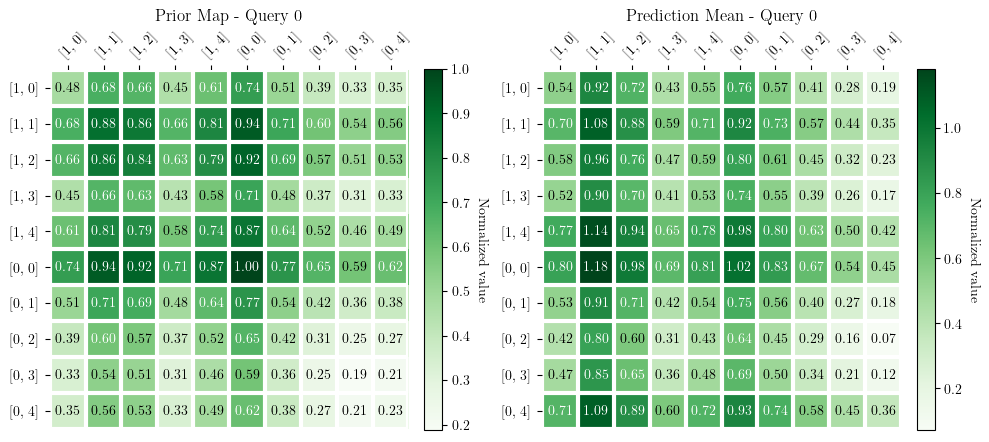

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844

Iter 1/10 - Loss: 1.329   lengthscale: 0.693   noise: 0.693
Iter 2/10 - Loss: 1.263   lengthscale: 0.744   noise: 0.644
Iter 3/10 - Loss: 1.201   lengthscale: 0.798   noise: 0.598
Iter 4/10 - Loss: 1.140   lengthscale: 0.854   noise: 0.554
Iter 5/10 - Loss: 1.081   lengthscale: 0.912   noise: 0.513
Iter 6/10 - Loss: 1.023   lengthscale: 0.972   noise: 0.474
Iter 7/10 - Loss: 0.967   lengthscale: 1.033   noise: 0.437
Iter 8/10 - Loss: 0.914   lengthscale: 1.096   noise: 0.402
Iter 9/10 - Loss: 0.863   lengthscale: 1.160   noise: 0.369
Iter 10/10 - Loss: 0.815   lengthscale: 1.224   noise: 0.339
Iter 1/10 - Loss: 0.760   lengthscale: 1.289   noise: 0.311
Iter 2/10 - Loss: 0.715   lengthscale: 1.362   noise: 0.285
Iter 3/10 - Loss: 0.674   lengthscale: 1.438   noise: 0.261
Iter 4/10 - Loss: 0.639   lengthscale: 1.515   noise: 0.239
Iter 5/10 - Loss: 0.606   lengthscale: 1.593   noise: 0.219
Iter 6/10 - Loss: 0.572   lengthscale: 1.673   noise: 0.200
Iter 7/10 - Loss: 0.537   lengthscale: 

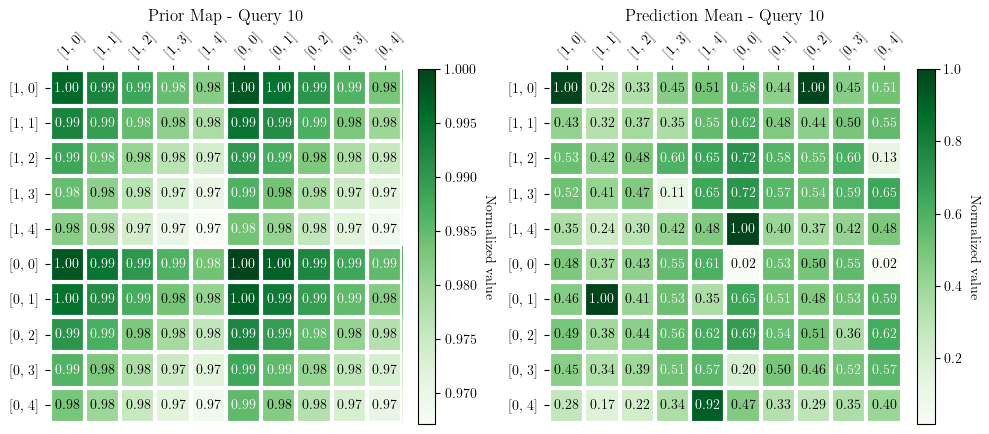

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844

Iter 1/10 - Loss: -0.196   lengthscale: 1.920   noise: 0.040
Iter 2/10 - Loss: -0.151   lengthscale: 1.835   noise: 0.037
Iter 3/10 - Loss: -0.196   lengthscale: 1.893   noise: 0.038
Iter 4/10 - Loss: -0.191   lengthscale: 1.937   noise: 0.039
Iter 5/10 - Loss: -0.175   lengthscale: 1.974   noise: 0.040
Iter 6/10 - Loss: -0.183   lengthscale: 2.015   noise: 0.040
Iter 7/10 - Loss: -0.197   lengthscale: 2.055   noise: 0.040
Iter 8/10 - Loss: -0.198   lengthscale: 2.085   noise: 0.039
Iter 9/10 - Loss: -0.190   lengthscale: 2.107   noise: 0.038
Iter 10/10 - Loss: -0.186   lengthscale: 2.129   noise: 0.037
Iter 1/10 - Loss: -0.226   lengthscale: 2.156   noise: 0.037
Iter 2/10 - Loss: -0.197   lengthscale: 2.245   noise: 0.034
Iter 3/10 - Loss: -0.229   lengthscale: 2.319   noise: 0.035
Iter 4/10 - Loss: -0.228   lengthscale: 2.350   noise: 0.037
Iter 5/10 - Loss: -0.216   lengthscale: 2.369   noise: 0.037
Iter 6/10 - Loss: -0.221   lengthscale: 2.407   noise: 0.037
Iter 7/10 - Loss: -0.23

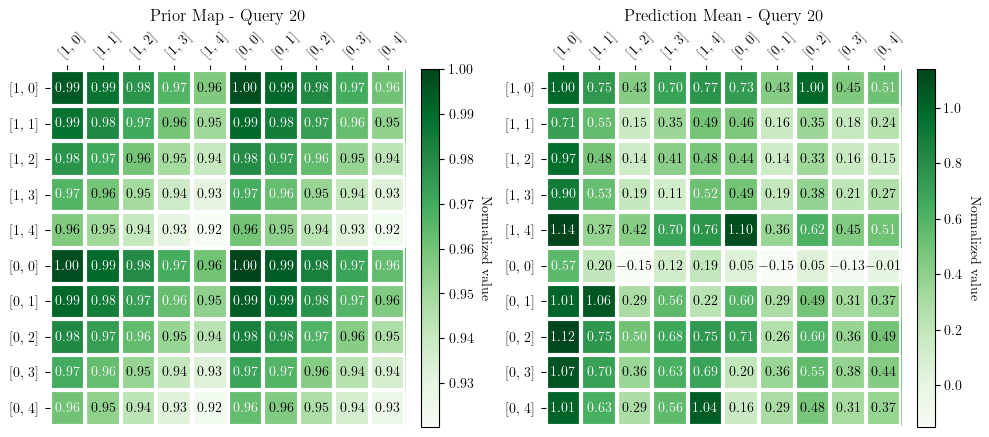

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844

Iter 1/10 - Loss: -0.439   lengthscale: 3.118   noise: 0.022
Iter 2/10 - Loss: -0.432   lengthscale: 3.022   noise: 0.024
Iter 3/10 - Loss: -0.439   lengthscale: 3.073   noise: 0.023
Iter 4/10 - Loss: -0.442   lengthscale: 3.140   noise: 0.021
Iter 5/10 - Loss: -0.439   lengthscale: 3.202   noise: 0.021
Iter 6/10 - Loss: -0.438   lengthscale: 3.257   noise: 0.021
Iter 7/10 - Loss: -0.441   lengthscale: 3.299   noise: 0.022
Iter 8/10 - Loss: -0.443   lengthscale: 3.321   noise: 0.023
Iter 9/10 - Loss: -0.441   lengthscale: 3.325   noise: 0.023
Iter 10/10 - Loss: -0.440   lengthscale: 3.317   noise: 0.023
Iter 1/10 - Loss: -0.460   lengthscale: 3.300   noise: 0.023
Iter 2/10 - Loss: -0.447   lengthscale: 3.204   noise: 0.021
Iter 3/10 - Loss: -0.461   lengthscale: 3.131   noise: 0.020
Iter 4/10 - Loss: -0.460   lengthscale: 3.049   noise: 0.020
Iter 5/10 - Loss: -0.455   lengthscale: 3.002   noise: 0.021
Iter 6/10 - Loss: -0.458   lengthscale: 3.018   noise: 0.022
Iter 7/10 - Loss: -0.46

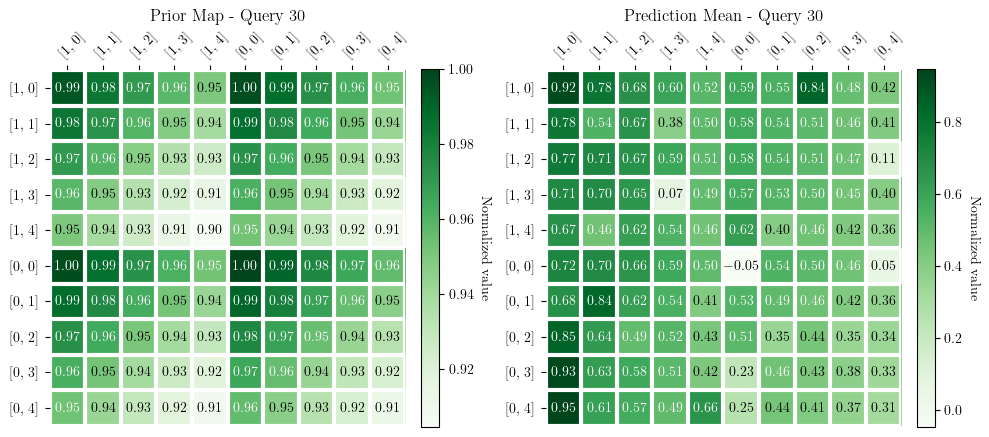

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)


Iter 1/10 - Loss: -0.596   lengthscale: 3.976   noise: 0.016
Iter 2/10 - Loss: -0.596   lengthscale: 4.074   noise: 0.017
Iter 3/10 - Loss: -0.596   lengthscale: 4.165   noise: 0.017
Iter 4/10 - Loss: -0.599   lengthscale: 4.258   noise: 0.016
Iter 5/10 - Loss: -0.599   lengthscale: 4.318   noise: 0.015
Iter 6/10 - Loss: -0.598   lengthscale: 4.320   noise: 0.015
Iter 7/10 - Loss: -0.598   lengthscale: 4.289   noise: 0.016
Iter 8/10 - Loss: -0.599   lengthscale: 4.238   noise: 0.016
Iter 9/10 - Loss: -0.600   lengthscale: 4.176   noise: 0.017
Iter 10/10 - Loss: -0.599   lengthscale: 4.107   noise: 0.017


C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:167: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]


Iter 1/10 - Loss: -0.613   lengthscale: 4.035   noise: 0.017
Iter 2/10 - Loss: -0.608   lengthscale: 3.937   noise: 0.015
Iter 3/10 - Loss: -0.614   lengthscale: 3.840   noise: 0.015
Iter 4/10 - Loss: -0.614   lengthscale: 3.770   noise: 0.016
Iter 5/10 - Loss: -0.612   lengthscale: 3.796   noise: 0.016
Iter 6/10 - Loss: -0.613   lengthscale: 3.851   noise: 0.016
Iter 7/10 - Loss: -0.614   lengthscale: 3.917   noise: 0.016
Iter 8/10 - Loss: -0.615   lengthscale: 3.977   noise: 0.016
Iter 9/10 - Loss: -0.613   lengthscale: 4.018   noise: 0.015
Iter 10/10 - Loss: -0.613   lengthscale: 4.036   noise: 0.015
Iter 1/10 - Loss: -0.627   lengthscale: 4.029   noise: 0.015
Iter 2/10 - Loss: -0.618   lengthscale: 3.931   noise: 0.014
Iter 3/10 - Loss: -0.627   lengthscale: 3.943   noise: 0.015
Iter 4/10 - Loss: -0.626   lengthscale: 3.977   noise: 0.016
Iter 5/10 - Loss: -0.623   lengthscale: 4.021   noise: 0.017
Iter 6/10 - Loss: -0.624   lengthscale: 4.073   noise: 0.016
Iter 7/10 - Loss: -0.62

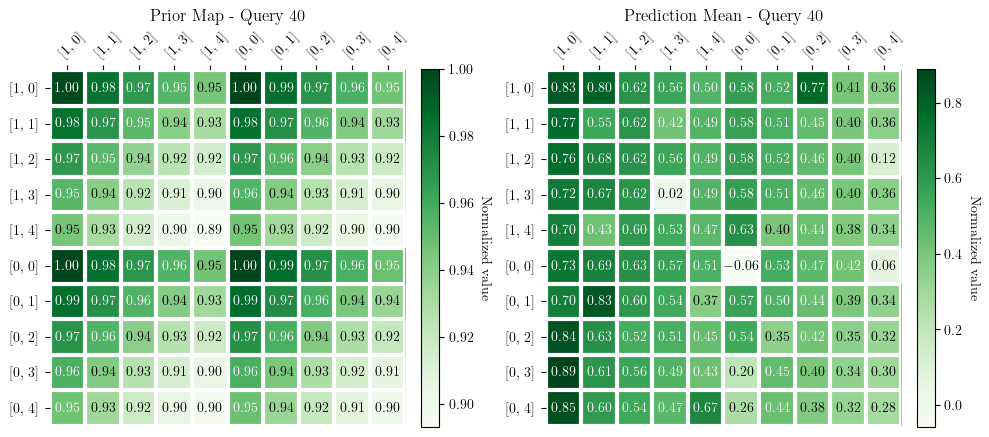

C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:116: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_1 = torch.tensor(response_1)
C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2915338110.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  response_2 = torch.tensor(response_2)


Iter 1/10 - Loss: -0.713   lengthscale: 4.468   noise: 0.013
Iter 2/10 - Loss: -0.708   lengthscale: 4.369   noise: 0.012
Iter 3/10 - Loss: -0.712   lengthscale: 4.353   noise: 0.012
Iter 4/10 - Loss: -0.712   lengthscale: 4.374   noise: 0.013
Iter 5/10 - Loss: -0.711   lengthscale: 4.411   noise: 0.013
Iter 6/10 - Loss: -0.711   lengthscale: 4.457   noise: 0.013
Iter 7/10 - Loss: -0.713   lengthscale: 4.501   noise: 0.013
Iter 8/10 - Loss: -0.713   lengthscale: 4.534   noise: 0.013
Iter 9/10 - Loss: -0.712   lengthscale: 4.550   noise: 0.012
Iter 10/10 - Loss: -0.712   lengthscale: 4.550   noise: 0.012


C:\Users\preda\AppData\Local\Temp\ipykernel_16820\2469844297.py:167: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  new_training_values_tampon[i] = Y[indices]


Iter 1/10 - Loss: -0.725   lengthscale: 4.534   noise: 0.013
Iter 2/10 - Loss: -0.720   lengthscale: 4.435   noise: 0.011
Iter 3/10 - Loss: -0.724   lengthscale: 4.422   noise: 0.012
Iter 4/10 - Loss: -0.724   lengthscale: 4.465   noise: 0.013
Iter 5/10 - Loss: -0.723   lengthscale: 4.523   noise: 0.014
Iter 6/10 - Loss: -0.723   lengthscale: 4.580   noise: 0.013
Iter 7/10 - Loss: -0.725   lengthscale: 4.616   noise: 0.013
Iter 8/10 - Loss: -0.725   lengthscale: 4.620   noise: 0.013
Iter 9/10 - Loss: -0.724   lengthscale: 4.597   noise: 0.012
Iter 10/10 - Loss: -0.724   lengthscale: 4.557   noise: 0.012
Iter 1/10 - Loss: -0.735   lengthscale: 4.507   noise: 0.012
Iter 2/10 - Loss: -0.729   lengthscale: 4.408   noise: 0.013
Iter 3/10 - Loss: -0.735   lengthscale: 4.339   noise: 0.013
Iter 4/10 - Loss: -0.734   lengthscale: 4.296   noise: 0.012
Iter 5/10 - Loss: -0.732   lengthscale: 4.317   noise: 0.012
Iter 6/10 - Loss: -0.733   lengthscale: 4.370   noise: 0.012
Iter 7/10 - Loss: -0.73

In [34]:

# Prepare data storage
#-------------------------------------------------------------------------
(array_repetition_2D, array_query_2D, array_exploration_score_2D, array_exploitation_score_2D, array_explr_mean_2D, array_explt_mean_2D, 
array_confUp_explr_mean_2D, array_confUp_explt_mean_2D, array_confLow_explr_mean_2D, array_confLow_explt_mean_2D, 
array_pins_coord_2D, array_pins_coord_exploration_2D, array_pins_count_exploration_2D, array_pins_count_2D) = create_data_storage(nbr_query, nbr_repetition, nbr_pins)

list_prior_map = []
#-----------------------------------------------------------------------------------------------------
# Start running the entire process for nbr_repetition
for repetition in range(nbr_repetition):
    startTime_repetition = time.time()
    print("repetition: ", repetition)
    prior_map_max = 0
    max_seen_resp_2D = 0
    max_seen_resp_1_1D = 0
    max_seen_resp_2_1D = 0
    response = torch.zeros(1)
    response1 = torch.zeros(1)
    response2 = torch.zeros(1)

    # Start training and evaluating over a number of query
    for q in range (nbr_query):
        if q == 0: 
            # Initialize 2 training data set
            train_x1_1D, train_y1_1D = random_initialization_1D(nbr_rdm_points_ini, emg, trainsC, max_seen_resp_1_1D)
            
            likelihood1 = gpytorch.likelihoods.GaussianLikelihood()
            model1 = ExactGPModel(train_x1_1D, train_y1_1D, likelihood1)
            
            model1.eval()
            likelihood1.eval()

            # Make a prediction, observed_pred = likelihood
            with gpytorch.settings.lazily_evaluate_kernels(state=False):
                # Prediction of Hierarchical Model
                observed_pred1 = make_prediction(model1, test_x_1D, likelihood1)

            y_mu1 = observed_pred1.mean
            
            for i in range(len(prior_map)):
                for j in range(len(prior_map)):
                    prior_map[i][j] = y_mu1[i] + y_mu1[j]
            prior_map_max = torch.max(prior_map)
            list_prior_map.append(np.array(prior_map/prior_map_max))
            
            # If first query, random initialization of the model
            train_x_2D, train_y_2D = random_initialization(nbr_rdm_points_ini, emg, trainsC, max_seen_resp_2D)
            train_x_2D = torch.tensor(train_x_2D, dtype = torch.float64)
            train_y_2D = torch.tensor(train_y_2D, dtype = torch.float64)

            prior_hierarchical_kernel = hierarchical_kernel('add', model1, model1)
            
            # Initialize likelihood and model
            likelihood = gpytorch.likelihoods.GaussianLikelihood()
            model = Hierarchical_GP(train_x_2D, train_y_2D, likelihood, prior_hierarchical_kernel, (prior_map/prior_map_max))

            # Get into evaluation (predictive posterior) mode
            model.eval()
            likelihood.eval()
            # Make a prediction, observed_pred = likelihood
            with gpytorch.settings.lazily_evaluate_kernels(state=False):
                # Prediction of Hierarchical Model
                observed_pred = make_Hierarchique_prediction(model, test_x_2D, likelihood)
            list_objective_mean_map.append(np.array(np.reshape(observed_pred.mean,(10, 10))))

        comparison(list_prior_map, list_objective_mean_map, q, Xmean_1D)
            
        # acquisition map based on 1D model prediction
        acquisition_map, hierar_y_mu = get_acquisition_map(kappa, observed_pred)
        
        # Get the coordinates of the next pins to exploite
        next_query_pins = get_next_query_pins(acquisition_map, test_x_2D)
        
        # Get the next query value
        next_query_value_random, next_query_value_mean = get_next_query_value(next_query_pins, X_2D, Y_2D)

        y_mu_point_a = get_y_mu_point_value(next_query_pins[0:2], y_mu1, test_x_1D)
        y_mu_point_b = get_y_mu_point_value(next_query_pins[2:4], y_mu1, test_x_1D)
        
        # next_query_value_random is the response of the system (emg)
        response_1, response_2 = compute_responses(y_mu_point_a, y_mu_point_b, next_query_value_random)

        response_1, max_seen_resp_1_1D = update_max_seen_response(response_1, max_seen_resp_1_1D)
        response_2, max_seen_resp_1_1D = update_max_seen_response(response_2, max_seen_resp_1_1D)
        next_query_value_random, max_seen_resp_2D = update_max_seen_response(next_query_value_random, max_seen_resp_2D)

        response = torch.tensor(next_query_value_random)
        response_1 = torch.tensor(response_1)
        response_2 = torch.tensor(response_2)
        
        # update unitary model with response_1 and response_2
        model1, likelihood1, train_x1_1D, train_y1_1D = update_model1_1D(model1, likelihood1, train_x1_1D, train_y1_1D, next_query_pins, response_1, response_2)
        
        model1.eval()
        likelihood1.eval()
        
        # Make a prediction, observed_pred = likelihood
        with gpytorch.settings.lazily_evaluate_kernels(state=False):
            observed_pred1 = make_prediction(model1, test_x_1D, likelihood1)
            
        y_mu1 = observed_pred1.mean

        for i in range(len(prior_map)):
            for j in range(len(prior_map)):
                prior_map[i][j] = y_mu1[i] + y_mu1[j]
        prior_map_max = torch.max(prior_map)
        
        list_prior_map.append(np.array(prior_map/prior_map_max))
        list_objective_mean_map.append(np.array(np.reshape(observed_pred.mean,(10, 10))))
        
        model.mean_module.map = torch.nn.Parameter(prior_map/prior_map_max)
                
        model = update_kernel_parameters(model, model1, model1)

        # Update training data by adding next_query_value to the train dataset
        train_x_2D, train_y_2D = update_training_data(train_x_2D, train_y_2D, next_query_pins, response)

        # Update the model with the new training data
        model.set_train_data(train_x_2D, train_y_2D, strict=False) # strict = False to add inputs with different shape

        with gpytorch.settings.lazily_evaluate_kernels(state=False):
            # Find optimal model hyperparameters
            model.train()
            likelihood.train()

            model, likelihood = Hoptimize(model, likelihood, training_iter, train_x_2D, train_y_2D, verbose=False)
            # Get into evaluation (predictive posterior) mode
            model.eval()
            likelihood.eval()
            
            # Make a prediction, observed_pred = likelihood, prediction_mean = mu
            observed_pred = make_Hierarchique_prediction(model, test_x_2D, likelihood)
            
                    #2D HIERARCHICAL MODEL
        #-----------------------------------------------------------------------------------------------#
        # Compute exploration and exploitation score
        exploration_score_2D, next_query_pins_exploration_2D = get_exploration_score(hierar_y_mu, ground_truth_max_2D, test_x_2D, X_2D, Y_2D)
        exploitation_score_2D = get_exploitation_score(next_query_value_mean, ground_truth_max_2D)
        # Record results and parameters
        # Query and repetitions
        array_repetition_2D[q + nbr_query * repetition] = repetition
        array_query_2D[q + nbr_query * repetition] = q
        # Scores
        array_exploration_score_2D[q + nbr_query * repetition] = exploration_score_2D
        array_exploitation_score_2D[q + nbr_query * repetition] = exploitation_score_2D
        # Pins selected
        array_pins_coord_2D[q + nbr_query * repetition][:] = next_query_pins
        array_pins_coord_exploration_2D[q + nbr_query * repetition][:] = next_query_pins_exploration_2D
        # Mean for each score and confidence level of a query over all rep
        array_explr_mean_2D[q] += (array_exploration_score_2D[q + nbr_query * repetition]) 
        array_explt_mean_2D[q] += (array_exploitation_score_2D[q + nbr_query * repetition])
        #-----------------------------------------------------------------------------------------------#

In [35]:

# Compute the mean on each line which accumulated value over repetitions
for q in range (nbr_query):
        array_explr_mean_2D[q] = array_explr_mean_2D[q]/nbr_repetition
        array_explt_mean_2D[q] = array_explt_mean_2D[q]/nbr_repetition

array_pins_count_2D = count_pin(array_pins_coord_2D, test_x_2D)
array_pins_count_exploration_2D = count_pin(array_pins_coord_exploration_2D, test_x_2D)  

data_dict_Hmodel={'query_number':array_query_2D,
                  'exploration_score':array_exploration_score_2D,
                  'exploitation_score':array_exploitation_score_2D,
                  'pins_coord_exploration':array_pins_coord_exploration_2D,
                  'pins_count_exploration':array_pins_count_exploration_2D,
                  'pins_coord_exploitation':array_pins_coord_2D,
                  'pins_count_exploitation':array_pins_count_2D,
                  'exploration_score_mean_repetition':array_explr_mean_2D,
                  'exploitation_score_mean_repetition':array_explt_mean_2D,
                  'kappa_value':kappa,
                  'nbr_of_query_per_rep':nbr_query,
                  'nbr_of_repetition':nbr_repetition,
                  'pts_of_ini':nbr_rdm_points_ini,
                  'emg':emg,
                  'prior_map':list_prior_map,
                  'objective_mean_map':list_objective_mean_map
                  }

print(array_pins_count_exploration_2D)

# Name format for saving data
file_name_H = 'HGPBO_data_' + current_datetime + '_k' + str(f'{kappa:02}') + '_emg' + str(emg) + 'iniPts' + str(f'{nbr_rdm_points_ini:02}')
# Save data
save_data(file_name_H, folder_of_the_day, workspace_folder, data_dict_Hmodel)
# Reset data storage for next loop (new kappa or nbr_ini, etc)
data_dict_Hmodel = reset_data_storage(data_dict_Hmodel)

[[array([1, 0, 1, 0], dtype=int64) 2]
 [array([1, 0, 1, 1], dtype=int64) 2]
 [array([1, 0, 1, 2], dtype=int64) 2]
 [array([1, 0, 1, 3], dtype=int64) 2]
 [array([1, 0, 1, 4], dtype=int64) 2]
 [array([1, 0, 0, 0], dtype=int64) 2]
 [array([1, 0, 0, 1], dtype=int64) 2]
 [array([1, 0, 0, 2], dtype=int64) 2]
 [array([1, 0, 0, 3], dtype=int64) 2]
 [array([1, 0, 0, 4], dtype=int64) 2]
 [array([1, 1, 1, 0], dtype=int64) 3]
 [array([1, 1, 1, 1], dtype=int64) 3]
 [array([1, 1, 1, 2], dtype=int64) 3]
 [array([1, 1, 1, 3], dtype=int64) 3]
 [array([1, 1, 1, 4], dtype=int64) 3]
 [array([1, 1, 0, 0], dtype=int64) 3]
 [array([1, 1, 0, 1], dtype=int64) 3]
 [array([1, 1, 0, 2], dtype=int64) 3]
 [array([1, 1, 0, 3], dtype=int64) 3]
 [array([1, 1, 0, 4], dtype=int64) 3]
 [array([1, 2, 1, 0], dtype=int64) 1]
 [array([1, 2, 1, 1], dtype=int64) 1]
 [array([1, 2, 1, 2], dtype=int64) 1]
 [array([1, 2, 1, 3], dtype=int64) 1]
 [array([1, 2, 1, 4], dtype=int64) 1]
 [array([1, 2, 0, 0], dtype=int64) 1]
 [array([1, 

#### Prior Map visualization

In [36]:
def update(changed_image):
    for im in images:
        if (changed_image.get_cmap() != im.get_cmap()
                or changed_image.get_clim() != im.get_clim()):
            im.set_cmap(changed_image.get_cmap())
            im.set_clim(changed_image.get_clim())

def prior_map_visualization(data_dict, nbr_query, Xmean_1D, Nrow, Ncol):
    font = {'weight' : 'normal',
           'size'   : 12}
    matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
    matplotlib.rc('text', usetex=True)
    list_of_priors_map = data_dict.get('prior_map')
        
    fig, axs = plt.subplots(Nrow, Ncol, figsize=(16, 9))
    #fig.tight_layout(rect=[0.1, 0.1, 0.1, 0.1]) 
    fig.suptitle('Prior Map at several queries')

    data = []
    print(nbr_query)
    for q in range(0, len(list_of_priors_map), nbr_repetition):
        data.append(list_of_priors_map[q])
    
    q_graph = 0
    map_indice = 0
    images = []
    for i in range(Nrow):
        for j in range(Ncol):
            images.append(axs[i, j].imshow(data[map_indice]))
            axs[i, j].label_outer()
            axs[i, j].set_title('Query ' + str(q_graph))
            axs[i, j].xaxis.set_ticks_position('top')
            axs[i, j].set_yticks(np.arange(len(Xmean_1D)), labels=Xmean_1D)
            axs[i, j].set_xticks(np.arange(len(Xmean_1D)), labels=Xmean_1D)
            plt.setp(axs[i, j].get_xticklabels(), rotation=45, ha="left", rotation_mode="anchor")
            map_indice = map_indice+1
            q_graph += nbr_repetition
    map_indice = 0
    q_graph = 0

    # Find the min and max of all colors for use in setting the color scale.
    vmin = min(image.get_array().min() for image in images)
    vmax = max(image.get_array().max() for image in images)
    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    for im in images:
        im.set_norm(norm)
        
    fig.colorbar(images[0], ax=axs, orientation='horizontal', fraction=.05, label='Normalized, 1 = strong prior')
    
    for im in images:
        im.callbacks.connect('changed', update)
    
    fig.savefig('HGP-BO_2D-prior_maps.pdf')
        

HGPBO_data_2024-07-04_09h-45min-51s_k05_emg4iniPts05.json
50


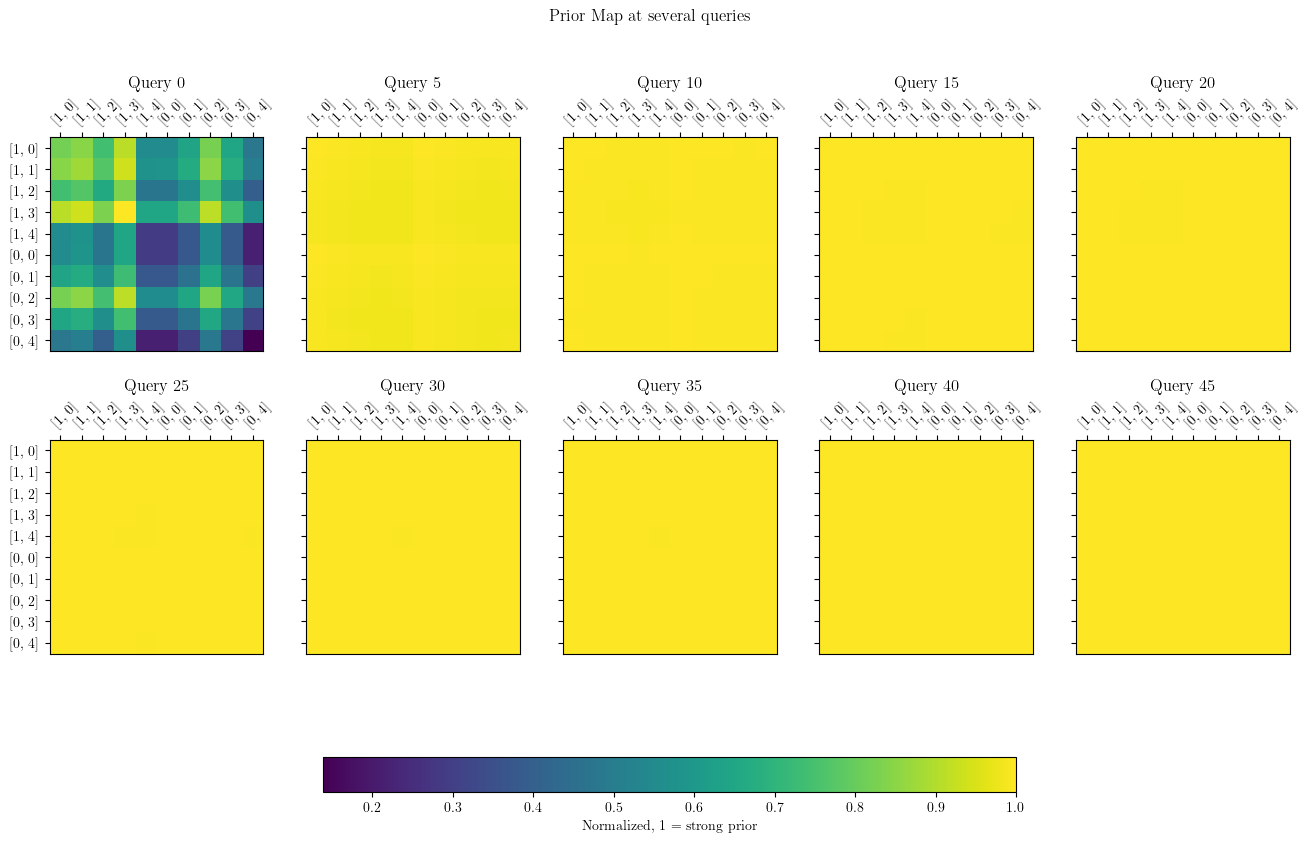

In [37]:
# Go to the folder of the day and plot data
os.chdir(folder_of_the_day)
for files in os.listdir(folder_of_the_day):
    print(files)
    if files != ("time_of_run.json"):
        if files.endswith(".json"):
            with open(files, 'r') as dict_json_file:
                data_dict = json.load(dict_json_file)
                prior_map_visualization(data_dict, nbr_query, Xmean_1D, 2, 5)
# Go back to workspace
os.chdir(workspace_folder)


50


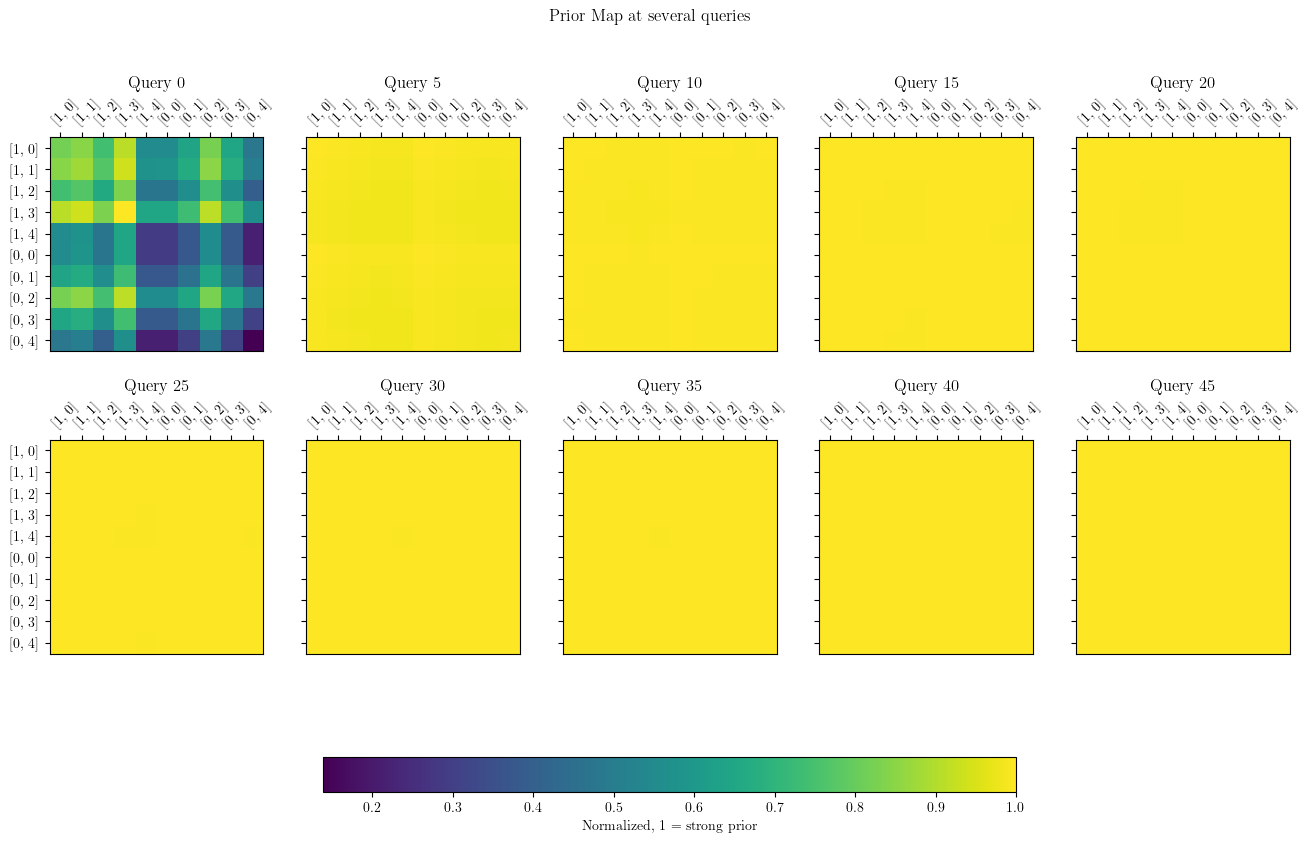

In [38]:
prior_map_visualization(data_dict_Hmodel, nbr_query, Xmean_1D, 2, 5)

#### Channels Queried visualization

In [39]:
def heatmap_querried(data, row_labels, col_labels, ax=None,
            cbar_kw=None, cbarlabel="", **kwargs):
    """
    Create a heatmap from a numpy array and two lists of labels.

    Parameters
    ----------
    data
        A 2D numpy array of shape (M, N).
    row_labels
        A list or array of length M with the labels for the rows.
    col_labels
        A list or array of length N with the labels for the columns.
    ax
        A `matplotlib.axes.Axes` instance to which the heatmap is plotted.  If
        not provided, use current axes or create a new one.  Optional.
    cbar_kw
        A dictionary with arguments to `matplotlib.Figure.colorbar`.  Optional.
    cbarlabel
        The label for the colorbar.  Optional.
    **kwargs
        All other arguments are forwarded to `imshow`.
    """
    
    if ax is None:
        ax = plt.gca()

    if cbar_kw is None:
        cbar_kw = {}

    # Plot the heatmap
    im = ax.imshow(data, **kwargs)
    
    # Create colorbar
    cbar = ax.figure.colorbar(im, fraction=0.046, pad=0.04, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    # Show all ticks and label them with the respective list entries.
    ax.set_xticks(np.arange(data.shape[1]), labels=col_labels)
    ax.set_yticks(np.arange(data.shape[0]), labels=row_labels)

    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=True, bottom=False,
                   labeltop=True, labelbottom=False)

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="left", rotation_mode="anchor")

    # Turn spines off and create white grid.
    ax.spines[:].set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar



def ch_querried_visualization(list_prior, Xmean_1D):
    
    font = {'weight' : 'normal',
           'size'   : 12}
    matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
    matplotlib.rc('text', usetex=True)
        
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 10))

    im1, cbar1 = heatmap_querried(list_prior[-1], Xmean_1D, Xmean_1D, ax=ax1,
                       cmap="Greens", cbarlabel="Normalized value")
    texts = annotate_heatmap(im1, data=list_prior[-1], valfmt="{x:.2f}")

    fig.tight_layout()
    plt.show()

### Visualization Functions

In [40]:
def visualization_function(data_file, files):
    font = {'weight' : 'normal',
           'size'   : 12}
    matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
    matplotlib.rc('text', usetex=True)

    nbr_pts_ini = data_dict.get('pts_of_ini')
    nbr_query = data_dict.get('nbr_of_query_per_rep')
    x_axis = np.arange(nbr_query)
    x_axis = x_axis + nbr_pts_ini
    
    # Get a fake point to link the plot to y = 0
    first_data_point = np.array(data_dict.get('exploitation_score_mean_repetition'))[0]
    fake_data_explt = np.zeros(2)
    fake_data_explt[1] = first_data_point
    fake_abs_explt = np.zeros(2)
    fake_abs_explt[0] = fake_abs_explt[1] = nbr_pts_ini
    
    first_data_point = np.array(data_dict.get('exploration_score_mean_repetition'))[0]
    fake_data_explr = np.zeros(2)
    fake_data_explr[1] = first_data_point
    fake_abs_explr = np.zeros(2)
    fake_abs_explr[0] = fake_abs_explr[1] = nbr_pts_ini
    
    # Exploration and exploitation score/query
    with torch.no_grad():
        fig, ax = plt.subplots()
        plt.figure(figsize=(8,5))

        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        #ax.scatter(for_plotting_query_number, data_dict.get('exploitation_score_mean_repetition'), c='red', marker ='x')
        ax.plot(fake_abs_explt, fake_data_explt, "r-", alpha=0.25)
        ax.plot(x_axis, data_dict.get('exploitation_score_mean_repetition'), "r-", label ='Exploitation score')
        #ax.fill_between(x_axis, data_dict.get('confidenceLow_exploitation'), data_dict.get('confidenceUp_exploitation'), alpha=0.15, color='orange')

        #ax.scatter(for_plotting_query_number, data_dict.get('exploration_score_mean_repetition'), c='blue', marker ='x')
        ax.plot(fake_abs_explr, fake_data_explr, "b-", alpha=0.25)
        ax.plot(x_axis, data_dict.get('exploration_score_mean_repetition'), "b-", label ='Exploration score')
        #ax.fill_between(x_axis, data_dict.get('confidenceLow_exploration'), data_dict.get('confidenceUp_exploration'), alpha=0.15, color='blue')
        
        ax.set_ylim([0, 1.2])
        ax.set_xlim([-5, nbr_query+nbr_pts_ini])
        
        ax.set_ylabel('\\textbf{Score}', fontsize=12,  fontweight='bold')
        ax.set_xlabel('\\textbf{Number of query}', fontsize=12, fontweight='bold')
        ax.grid(True, linestyle ="--", color = 'grey')
        ax.legend(loc = "lower right", fontsize='large')
        
        ax.set_title('HGP-BO_2D ' + str(data_dict.get('nbr_of_repetition')) + ' repetitions of ' + str(data_dict.get('nbr_of_query_per_rep')) + ' query ' + 'kappa ' + str(data_dict.get('kappa_value'))) 
        fig.savefig('HGP-BO_2D ' + str(data_dict.get('nbr_of_repetition')) + ' repetitions of ' + str(data_dict.get('nbr_of_query_per_rep')) + ' query ' + 'kappa ' + str(data_dict.get('kappa_value')) + '.pdf')

        if 'HGP-BO' in files:      
            ax.set_title('HGP-BO_2D ' + str(data_dict.get('nbr_of_repetition')) + ' repetitions of ' + str(data_dict.get('nbr_of_query_per_rep')) + ' query ' + 'kappa ' + str(data_dict.get('kappa_value'))) 
            fig.savefig('HGP-BO_2D ' + str(data_dict.get('nbr_of_repetition')) + ' repetitions of ' + str(data_dict.get('nbr_of_query_per_rep')) + ' query ' + 'kappa ' + str(data_dict.get('kappa_value')) + '.pdf')
        elif 'GPBO_1' in files:      
            ax.set_title('GPBO_1 ' + str(data_dict.get('nbr_of_repetition')) + ' repetitions of ' + str(data_dict.get('nbr_of_query_per_rep')) + ' query ' + 'kappa ' + str(data_dict.get('kappa_value'))) 
            fig.savefig('GPBO_1 ' + str(data_dict.get('nbr_of_repetition')) + ' repetitions of ' + str(data_dict.get('nbr_of_query_per_rep')) + ' query ' + 'kappa ' + str(data_dict.get('kappa_value')) + '.pdf')
        elif 'GPBO_2' in files:      
            ax.set_title('GPBO_2 ' + str(data_dict.get('nbr_of_repetition')) + ' repetitions of ' + str(data_dict.get('nbr_of_query_per_rep')) + ' query ' + 'kappa ' + str(data_dict.get('kappa_value'))) 
            fig.savefig('GPBO_2 ' + str(data_dict.get('nbr_of_repetition')) + ' repetitions of ' + str(data_dict.get('nbr_of_query_per_rep')) + ' query ' + 'kappa ' + str(data_dict.get('kappa_value')) + '.pdf')

#### Plotting

HGP-BO_2D-prior_maps.pdf
HGPBO_data_2024-07-04_09h-45min-51s_k05_emg4iniPts05.json


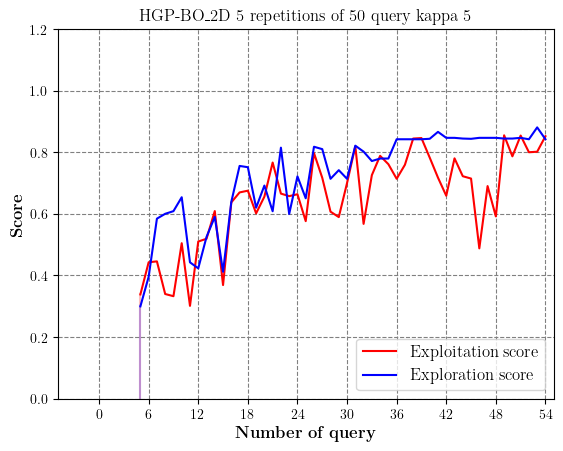

<Figure size 800x500 with 0 Axes>

In [41]:
# Go to the folder of the day and plot data
os.chdir(folder_of_the_day)

for files in os.listdir(folder_of_the_day):
    print(files)
    if files != ("time_of_run.json"):
        if files.endswith(".json"):
            with open(files, 'r') as dict_json_file:
                data_dict = json.load(dict_json_file)
                visualization_function(data_dict, files)

# Go back to workspace
os.chdir(workspace_folder)

#### Prior Map visualization

HGP-BO_2D 5 repetitions of 50 query kappa 5.pdf
HGP-BO_2D-prior_maps.pdf
HGPBO_data_2024-07-04_09h-45min-51s_k05_emg4iniPts05.json


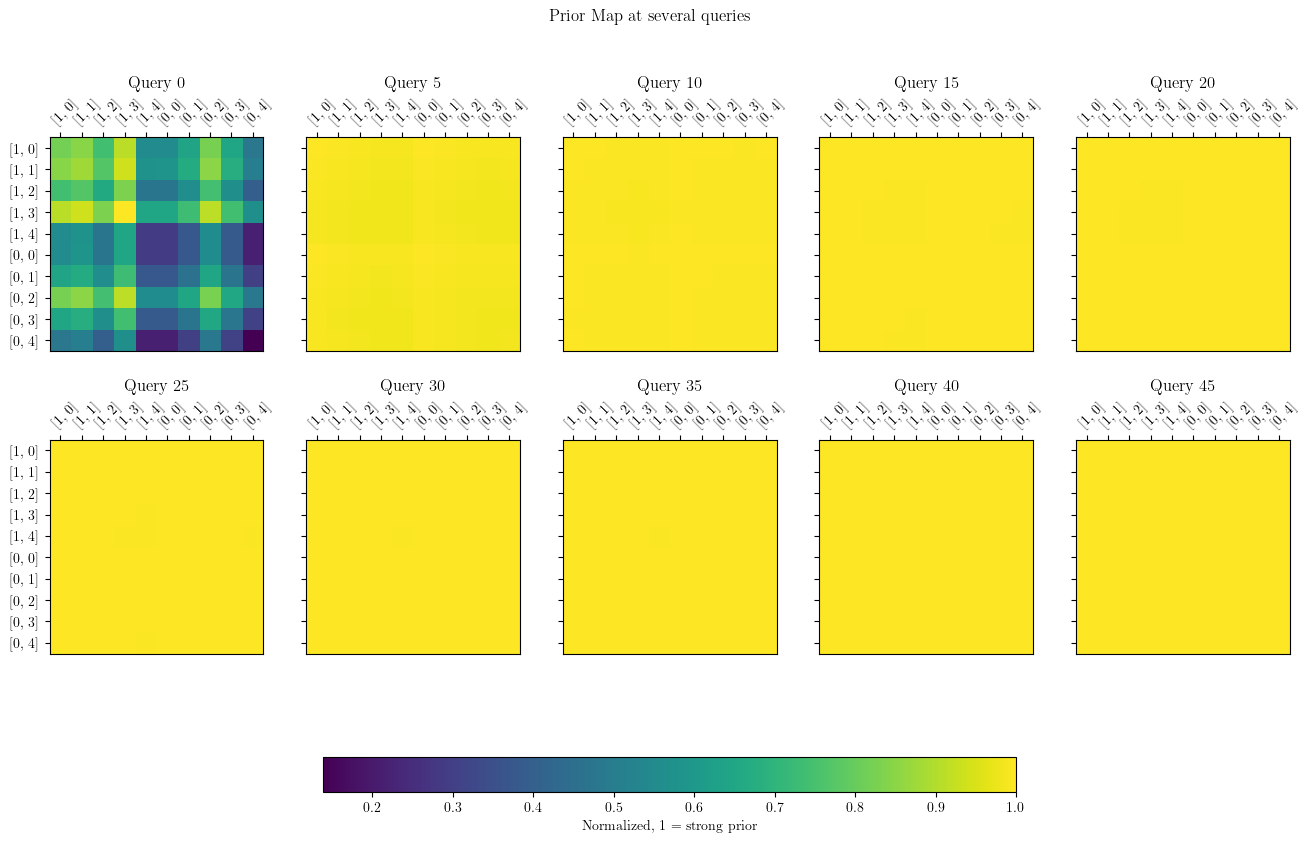

In [42]:
def update(changed_image):
    for im in images:
        if (changed_image.get_cmap() != im.get_cmap()
                or changed_image.get_clim() != im.get_clim()):
            im.set_cmap(changed_image.get_cmap())
            im.set_clim(changed_image.get_clim())

def prior_map_visualization(data_dict, nbr_query, Xmean_1D, Nrow, Ncol):
    font = {'weight' : 'normal',
           'size'   : 12}
    matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
    matplotlib.rc('text', usetex=True)
    list_of_priors_map = data_dict.get('prior_map')
        
    fig, axs = plt.subplots(Nrow, Ncol, figsize=(16, 9))
    #fig.tight_layout(rect=[0.1, 0.1, 0.1, 0.1]) 
    fig.suptitle('Prior Map at several queries')

    data = []
    for q in range(0, len(list_of_priors_map), nbr_repetition):
        data.append(list_of_priors_map[q])
    
    q_graph = 0
    map_indice = 0
    images = []
    for i in range(Nrow):
        for j in range(Ncol):
            images.append(axs[i, j].imshow(data[map_indice]))
            axs[i, j].label_outer()
            axs[i, j].set_title('Query ' + str(q_graph))
            axs[i, j].xaxis.set_ticks_position('top')
            axs[i, j].set_yticks(np.arange(len(Xmean_1D)), labels=Xmean_1D)
            axs[i, j].set_xticks(np.arange(len(Xmean_1D)), labels=Xmean_1D)
            plt.setp(axs[i, j].get_xticklabels(), rotation=45, ha="left", rotation_mode="anchor")
            map_indice = map_indice+1
            q_graph += nbr_repetition
    map_indice = 0
    q_graph = 0

    # Find the min and max of all colors for use in setting the color scale.
    vmin = min(image.get_array().min() for image in images)
    vmax = max(image.get_array().max() for image in images)
    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    for im in images:
        im.set_norm(norm)
        
    fig.colorbar(images[0], ax=axs, orientation='horizontal', fraction=.05, label='Normalized, 1 = strong prior')
    
    for im in images:
        im.callbacks.connect('changed', update)
        
# Go to the folder of the day and plot data
os.chdir(folder_of_the_day)
for files in os.listdir(folder_of_the_day):
    print(files)
    if files != ("time_of_run.json"):
        if files.endswith(".json"):
            with open(files, 'r') as dict_json_file:
                data_dict = json.load(dict_json_file)
                prior_map_visualization(data_dict, nbr_query, Xmean_1D, 2, 5)
# Go back to workspace
os.chdir(workspace_folder)

#### Exploration Visualization Function

HGPBO_data_2024-07-04_09h-45min-51s_k05_emg4iniPts05.json


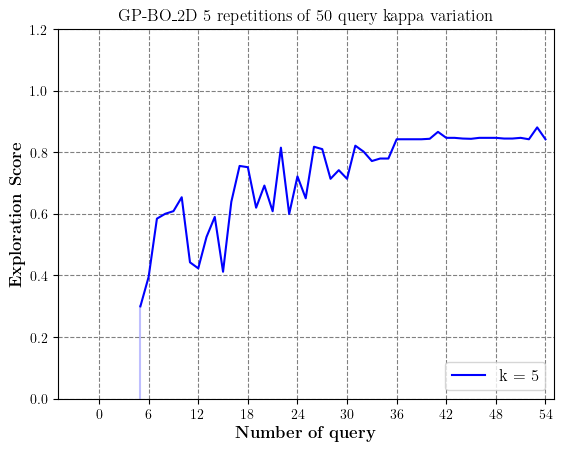

<Figure size 800x500 with 0 Axes>

In [43]:
def exploration_visualization_function(folder_data_path, nbr_query, nbr_pts_ini):

    fig, ax = plt.subplots()
    plt.figure(figsize=(8,5))
    
    for files in os.listdir(folder_data_path):
        if files != ("time_of_run.json"):
            if files.endswith(".json"):
                with open(files, 'r') as dict_json_file:
                    data_dict = json.load(dict_json_file)

                # Plot all exploration score for corresponding repetitions
                # Get a fake point to link the plot to y = 0
                print(files)
                nbr_pts_ini = data_dict.get('pts_of_ini')
                nbr_query = data_dict.get('nbr_of_query_per_rep')
                x_axis = np.arange(nbr_query)
                x_axis = x_axis + nbr_pts_ini

                first_data_point = np.array(data_dict.get('exploration_score_mean_repetition'))[0]
                fake_data_explr = np.zeros(2)
                fake_data_explr[1] = first_data_point
                fake_abs_explr = np.zeros(2)
                fake_abs_explr[0] = fake_abs_explr[1] = nbr_pts_ini

                #ax.scatter(for_plotting_query_number, data_dict.get('exploration_score_mean_repetition'), marker ='x')
                ax.plot(fake_abs_explr, fake_data_explr, "b-", alpha=0.25)
                ax.plot(x_axis, data_dict.get('exploration_score_mean_repetition'), "b-", label = 'k = ' + str(data_dict.get('kappa_value')))

    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_ylabel('\\textbf{Exploration Score}', fontsize=12,  fontweight='bold')
    ax.set_xlabel('\\textbf{Number of query}', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle ="--", color = 'grey')
    ax.legend(loc = "lower right", fontsize='large')
    ax.set_title('GP-BO_2D ' + str(nbr_repetition) + ' repetitions of ' + str(nbr_query) + ' query ' + 'kappa variation') 
 
    ax.set_ylim([0, 1.2])
    ax.set_xlim([-5, nbr_query+nbr_pts_ini])

    font = {'weight' : 'normal',
           'size'   : 12}
    matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
    matplotlib.rc('text', usetex=True)
    
    fig.savefig('GP-BO_2D' + str(data_dict.get('nbr_of_query_per_rep')) + '_query ' + '_kappa_variation_ExplorationScore.pdf')
    
    
# Go to the folder of the day and plot data
os.chdir(folder_of_the_day)

# Plot all exploration score
exploration_visualization_function(folder_of_the_day, nbr_query, nbr_rdm_points_data)

# Go back to workspace
os.chdir(workspace_folder)

#### Exploitation Visualization Function

HGPBO_data_2024-07-04_09h-45min-51s_k05_emg4iniPts05.json


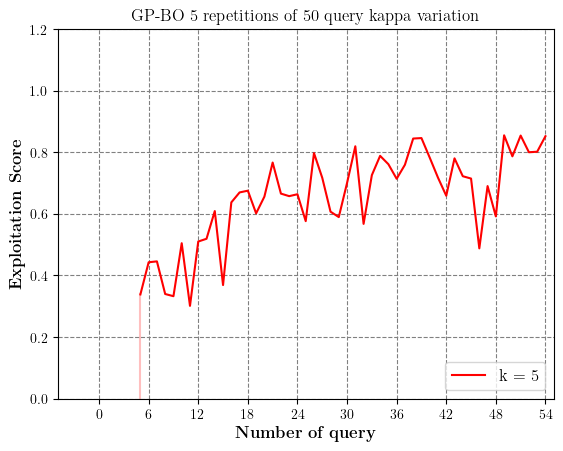

<Figure size 800x500 with 0 Axes>

In [44]:
def exploitation_visualization_function(folder_data_path):
    fig, ax = plt.subplots()
    plt.figure(figsize=(8,5))
    
    for files in os.listdir(folder_data_path):
        if files != ("time_of_run.json"):
            if files.endswith(".json"):
                with open(files, 'r') as dict_json_file:
                    data_dict = json.load(dict_json_file)

                print(files)
                # Plot all exploitation score for corresponding repetitions
                # Get a fake point to link the plot to y = 0
                nbr_pts_ini = data_dict.get('pts_of_ini')
                nbr_query = data_dict.get('nbr_of_query_per_rep')
                x_axis = np.arange(nbr_query)
                x_axis = x_axis + nbr_pts_ini
                first_data_point = np.array(data_dict.get('exploitation_score_mean_repetition'))[0]
                fake_data_explt = np.zeros(2)
                fake_data_explt[1] = first_data_point
                fake_abs_explt = np.zeros(2)
                fake_abs_explt[0] = fake_abs_explt[1] = nbr_pts_ini
                #ax.scatter(for_plotting_query_number, data_dict.get('exploitation_score_mean_repetition'), marker ='x')
                ax.plot(fake_abs_explt, fake_data_explt, "r-",  alpha=0.25)
                ax.plot(x_axis, data_dict.get('exploitation_score_mean_repetition'), "r-", label = 'k = ' + str(data_dict.get('kappa_value')))

    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_ylabel('\\textbf{Exploitation Score}', fontsize=12,  fontweight='bold')
    ax.set_xlabel('\\textbf{Number of query}', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle ="--", color = 'grey')
    ax.legend(loc = "lower right", fontsize='large')
    ax.set_title('GP-BO ' + str(nbr_repetition) + ' repetitions of ' + str(nbr_query) + ' query ' + 'kappa variation') 
 
    ax.set_ylim([0, 1.2])
    ax.set_xlim([-5, nbr_query+nbr_pts_ini])

    font = {'weight' : 'normal',
           'size'   : 12}
    matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
    matplotlib.rc('text', usetex=True)

    fig.savefig('GP-BO_' + str(nbr_query) + '_query ' + '_kappa_variation_ExploitationScore.pdf')
    
# Go to the folder of the day and plot data
os.chdir(folder_of_the_day)

# Plot all exploitation score
exploitation_visualization_function(folder_of_the_day)

# Go back to workspace
os.chdir(workspace_folder)